In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import matplotlib
from matplotlib.colors import Normalize
from pathlib import Path
import glob
import re

from collections.abc import Iterable

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Definitions

In [2]:
#NEW
"""
Publication-quality plot: log N_d(t) vs interaction step
for the LLM Naming Game at different decoding temperatures.

Designed for APS (Physical Review) single-column or double-column format.
"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from pathlib import Path
import glob
import re

# ── APS-compatible style ────────────────────────────────────────────────
matplotlib.rcParams.update({
    # Font settings — serif + mathtext (usetex fallback for environments without full TeX)
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif', 'Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    # Tick style
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    # Lines
    'lines.linewidth': 1.2,
    # Axes
    'axes.linewidth': 0.8,
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.handlelength': 1.8,
    # Savefig
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
})

# ── APS figure widths (inches) ──────────────────────────────────────────
APS_SINGLE_COL = 3.375    # single-column figure
APS_DOUBLE_COL = 6.975    # double-column figure


# ── Helper: load all seed files for a given (model, temp) ───────────────
def load_results(folder, type, model_name, seed, experiment, temp):
    """
    Load a single result file.
    Canonical filename example:
        num_of_diff_words_seed-4_na90-n12e4_phi3-14b_log_T-0.6.json
    Temperature is kept as-is with a dot: 0.05, 0.2, 0.4, ..., 2.0, 5.0
    """
    temp_str = f"{temp:g}"  # 0.05 → "0.05", 2.0 → "2", 5.0 → "5"
    if '.' not in temp_str:
        temp_str += '.0'

    # Primary: dot format  (T-0.6)
    fname = f"{type}_seed-{seed}_{experiment}_{model_name}_log_T-{temp_str}.json"
    path = Path(folder) / fname
    if path.exists():
        return pd.read_json(path)

    # Fallback: underscore format (T-0_6), for legacy / uploaded samples
    temp_str_us = temp_str.replace('.', '_')
    fname_us = f"{type}_seed-{seed}_{experiment}_{model_name}_log_T-{temp_str_us}.json"
    path_us = Path(folder) / fname_us
    if path_us.exists():
        return pd.read_json(path_us)

    raise FileNotFoundError(
        f"File not found for T={temp}, seed={seed}. Tried:\n"
        f"  {path}\n  {path_us}"
    )


def outdates_collect_seeds(folder, type, model_name, experiment, temp, seeds, load_fn=None):
    """
    Collect diff_word_count arrays across seeds for a single temperature.
    Returns a 2-D numpy array of shape (n_seeds_found, n_steps).
    """
    _loader = load_fn if load_fn is not None else load_results
    arrays = []
    for seed in seeds:
        try:
            df = _loader(folder, type, model_name, seed, experiment, temp)
            arrays.append(df['diff_word_count'].values.astype(float))
        except (FileNotFoundError, ValueError) as e:
            # Print warning so user sees what's missing
            pass
    if not arrays:
        print(f"  ⚠  No data found for T={temp} (seeds={seeds})")
        return None
    # Truncate to shortest run (in case seeds differ in length)
    min_len = min(len(a) for a in arrays)
    print(f"  T={temp}: {len(arrays)} seed(s) loaded, {min_len} steps")
    return np.stack([a[:min_len] for a in arrays], axis=0)

def collect_seeds(folder, type, model_name, experiment, temp, seeds,
                         load_fn=None, pad_mode='nan'):
    """
    Collect diff_word_count arrays across seeds for a single temperature.
    Pads shorter runs to the length of the longest run.
 
    Parameters
    ----------
    folder, type, model_name, experiment, temp, seeds :
        Same as collect_seeds.
    load_fn : callable, optional
        Custom loader: load_fn(folder, type, model_name, seed, experiment, temp) → DataFrame.
        If None, uses built-in loader with dot/underscore fallback.
    pad_mode : str
        'ffill' → pad with last known value (default).
                  Physically sensible: if a run reached consensus (N_d=1),
                  it stays there. If it didn't, it holds at its last N_d.
        'nan'   → pad with NaN. Shorter runs are excluded from
                  mean/std at steps beyond their length.
                  NOTE: requires using np.nanmean / np.nanstd downstream
                  (plot_nd_vs_steps already does this).
 
    Returns
    -------
    np.ndarray of shape (n_seeds_found, max_len)
        If pad_mode='ffill': regular float array, no NaNs.
        If pad_mode='nan': float array with NaN where data is missing.
    Returns None if no seeds found.
    """
    # ── Default loader (same logic as plot_nd_vs_steps.load_results) ────
    def _default_loader(folder, type, model_name, seed, experiment, temp):
        temp_str = f"{temp:g}"
        if '.' not in temp_str:
            temp_str += '.0'
        for ts in [temp_str, temp_str.replace('.', '_')]:
            fname = f"{type}_seed-{seed}_{experiment}_{model_name}_log_T-{ts}.json"
            path = Path(folder) / fname
            if path.exists():
                return pd.read_json(path)
        raise FileNotFoundError(f"No file for T={temp}, seed={seed}")
 
    _loader = load_fn if load_fn is not None else _default_loader
 
    arrays = []
    for seed in seeds:
        try:
            df = _loader(folder, type, model_name, seed, experiment, temp)
            arrays.append(df['diff_word_count'].values.astype(float))
        except (FileNotFoundError, ValueError):
            pass
 
    if not arrays:
        print(f"  ⚠  No data found for T={temp} (seeds={seeds})")
        return None
 
    # Pad to longest run
    max_len = max(len(a) for a in arrays)
    min_len = min(len(a) for a in arrays)
    n_seeds = len(arrays)
 
    padded = np.full((n_seeds, max_len), np.nan)
    for i, a in enumerate(arrays):
        padded[i, :len(a)] = a
        if pad_mode == 'ffill' and len(a) < max_len:
            padded[i, len(a):] = a[-1]  # forward-fill with last value
 
    if min_len < max_len:
        print(f"  T={temp}: {n_seeds} seed(s) loaded, "
              f"lengths {min_len}–{max_len} steps "
              f"(padded with {'last value' if pad_mode == 'ffill' else 'NaN'})")
    else:
        print(f"  T={temp}: {n_seeds} seed(s) loaded, {max_len} steps")
 
    return padded


# ── Smoothing utility (optional, useful for noisy runs) ─────────────────
def smooth(y, window=1):
    """Simple moving average. window=1 means no smoothing."""
    if window <= 1:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='same')

# ── Main plotting function ──────────────────────────────────────────────
def plot_nd_vs_steps(
    folder: str,
    model_name: str,
    experiment: str,
    seeds: list,
    list_of_temp: list,
    deterministic_path: str = None,
    max_steps: int = None,
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    smoothing_window: int = 1,
    subsample: int = 50,        # plot every N-th point (keeps PDF light)
    show_bands: bool = True,
    band_alpha: float = 0.18,
    band_type: str = 'sem',      # 'sem' or 'std'
    ylabel_log: bool = True,
    use_colorbar: bool = False,  # True → colorbar, False → legend
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,         # pass existing axis for multi-panel figures
    load_fn: callable = None,    # custom loader: load_fn(folder, type, model_name, seed, experiment, temp) → DataFrame
):
    """
    Publication-quality plot of log N_d(t) vs step for different temperatures.
 
    Parameters
    ----------
    folder : path to results directory
    model_name : e.g. 'phi3-14b'
    experiment : e.g. 'na1p5e2-ns9e4'
    seeds : list of seed integers
    list_of_temp : list of temperature floats
    deterministic_path : path to deterministic NG JSON (optional)
    max_steps : truncate x-axis (None = auto)
    figsize : (width, height) in inches; defaults to APS single-column
    cmap_name : colormap name
    smoothing_window : moving average window (1 = off)
    subsample : plot every N-th point to reduce file size
    show_bands : whether to show ±1 std bands
    band_alpha : transparency of bands
    ylabel_log : if True label y as ln N_d(t), else N_d(t)
    use_colorbar : if True, use a colorbar for T instead of a legend
    output_path : save path (e.g. 'fig_nd.pdf')
    title : optional panel title, e.g. '(a) phi3:14b'
    ax : optional pre-existing Axes object
    load_fn : optional custom loader function with same signature as load_results.
              If your notebook already defines load_results(), just pass load_fn=load_results.
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.75)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
 
    # ── Colormap ────────────────────────────────────────────────────────
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
 
    # ── Deterministic baseline ──────────────────────────────────────────
    if deterministic_path is not None:
        df_det = pd.read_json(deterministic_path)
        y_det = df_det['diff_word_count'].values.astype(float)
        if max_steps:
            y_det = y_det[:max_steps]
        x_det = np.arange(len(y_det))
        log_y_det = np.log(np.maximum(y_det, 1e-30))  # guard log(0)
        ax.plot(x_det[::subsample], log_y_det[::subsample],
                color='black', lw=1.8, ls='-', label='Det. NG', zorder=10)
 
    # ── Temperature curves ──────────────────────────────────────────────
    for temp in list_of_temp:
        data = collect_seeds(folder, 'num_of_diff_words',
                             model_name, experiment, temp, seeds,
                             load_fn=load_fn)
        if data is None:
            continue
 
        if max_steps:
            data = data[:, :max_steps]
 
        # Log transform (guard zeros)
        log_data = np.log(np.maximum(data, 1e-30))
        # Where original data was NaN (padded), keep NaN in log space
        log_data[np.isnan(data)] = np.nan
 
        mean_curve = np.nanmean(log_data, axis=0)
        std_curve  = np.nanstd(log_data, axis=0)
        # Count of non-NaN seeds at each step (for SEM)
        n_valid    = np.sum(~np.isnan(log_data), axis=0)
        n_seeds    = log_data.shape[0]
 
        # Scale band: std or sem
        if band_type == 'sem':
            band_curve = std_curve / np.sqrt(np.maximum(n_valid, 1))
        else:
            band_curve = std_curve
 
        # Optional smoothing
        mean_curve = smooth(mean_curve, smoothing_window)
        band_curve = smooth(band_curve, smoothing_window)
 
        steps = np.arange(len(mean_curve))
        color = cmap(norm(temp))
 
        # Subsample for lighter files
        idx = slice(None, None, subsample)
 
        if use_colorbar:
            ax.plot(steps[idx], mean_curve[idx], color=color, zorder=5)
        else:
            ax.plot(steps[idx], mean_curve[idx], color=color,
                    label=rf'$T={temp}$', zorder=5)
 
        if show_bands and n_seeds > 1:
            ax.fill_between(
                steps[idx],
                (mean_curve - band_curve)[idx],
                (mean_curve + band_curve)[idx],
                color=color, alpha=band_alpha, lw=0, zorder=2,
            )
 
    # ── Axes labels and formatting ──────────────────────────────────────
    ax.set_xlabel(r'Interaction step, $t$')
    if ylabel_log:
        ax.set_ylabel(r'$\ln\, N_d(t)$')
    else:
        ax.set_ylabel(r'$N_d(t)$')
 
    if title:
        ax.set_title(title, loc='left', fontsize=10)
 
    # Rescale x-axis to units of 10^3 for readability
    if max_steps and max_steps >= 1e4:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(
                lambda x, _: f'{x/1e3:.0f}' if x >= 1e3 else f'{x/1e3:.1f}'))
        ax.set_xlabel(r'Interaction step, $t\;[\times 10^3]$')
 
    # ── Colorbar or Legend ──────────────────────────────────────────────
    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=10)
        cbar.ax.tick_params(labelsize=8)
        # Add deterministic NG to a small legend if present
        if deterministic_path is not None:
            ax.legend(loc='upper right', fontsize=7.5,
                      handlelength=1.5, borderpad=0.3)
    else:
        ncol = 2 if len(list_of_temp) > 6 else 1
        ax.legend(loc='upper right', ncol=ncol, columnspacing=0.8,
                  handletextpad=0.4, borderpad=0.4, labelspacing=0.35)
 
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=-0.3)
 
    if own_fig:
        fig.tight_layout(pad=0.3)
 
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")
 
    return fig, ax


# ── Main plotting function ──────────────────────────────────────────────
def outdates2_plot_nd_vs_steps(
    folder: str,
    model_name: str,
    experiment: str,
    seeds: list,
    list_of_temp: list,
    deterministic_path: str = None,
    max_steps: int = None,
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    smoothing_window: int = 1,
    subsample: int = 50,        # plot every N-th point (keeps PDF light)
    show_bands: bool = True,
    band_alpha: float = 0.18,
    band_type: str = 'sem',      # 'sem' or 'std'
    ylabel_log: bool = True,
    use_colorbar: bool = False,  # True → colorbar, False → legend
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,         # pass existing axis for multi-panel figures
    load_fn: callable = None,    # custom loader: load_fn(folder, type, model_name, seed, experiment, temp) → DataFrame
):
    """
    Publication-quality plot of log N_d(t) vs step for different temperatures.

    Parameters
    ----------
    folder : path to results directory
    model_name : e.g. 'phi3-14b'
    experiment : e.g. 'na1p5e2-ns9e4'
    seeds : list of seed integers
    list_of_temp : list of temperature floats
    deterministic_path : path to deterministic NG JSON (optional)
    max_steps : truncate x-axis (None = auto)
    figsize : (width, height) in inches; defaults to APS single-column
    cmap_name : colormap name
    smoothing_window : moving average window (1 = off)
    subsample : plot every N-th point to reduce file size
    show_bands : whether to show ±1 std bands
    band_alpha : transparency of bands
    ylabel_log : if True label y as ln N_d(t), else N_d(t)
    use_colorbar : if True, use a colorbar for T instead of a legend
    output_path : save path (e.g. 'fig_nd.pdf')
    title : optional panel title, e.g. '(a) phi3:14b'
    ax : optional pre-existing Axes object
    load_fn : optional custom loader function with same signature as load_results.
              If your notebook already defines load_results(), just pass load_fn=load_results.
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.75)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # ── Colormap ────────────────────────────────────────────────────────
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    # ── Deterministic baseline ──────────────────────────────────────────
    if deterministic_path is not None:
        df_det = pd.read_json(deterministic_path)
        y_det = df_det['diff_word_count'].values.astype(float)
        if max_steps:
            y_det = y_det[:max_steps]
        x_det = np.arange(len(y_det))
        log_y_det = np.log(np.maximum(y_det, 1e-30))  # guard log(0)
        ax.plot(x_det[::subsample], log_y_det[::subsample],
                color='black', lw=1.8, ls='-', label='Det. NG', zorder=10)

    # ── Temperature curves ──────────────────────────────────────────────
    for temp in list_of_temp:
        data = collect_seeds(folder, 'num_of_diff_words',
                             model_name, experiment, temp, seeds,
                             load_fn=load_fn)
        if data is None:
            continue

        if max_steps:
            data = data[:, :max_steps]

        # Log transform (guard zeros)
        log_data = np.log(np.maximum(data, 1e-30))

        mean_curve = log_data.mean(axis=0)
        std_curve  = log_data.std(axis=0)
        n_seeds    = log_data.shape[0]

        # Scale band: std or sem
        if band_type == 'sem' and n_seeds > 1:
            band_curve = std_curve / np.sqrt(n_seeds)
        else:
            band_curve = std_curve

        # Optional smoothing
        mean_curve = smooth(mean_curve, smoothing_window)
        band_curve = smooth(band_curve, smoothing_window)

        steps = np.arange(len(mean_curve))
        color = cmap(norm(temp))

        # Subsample for lighter files
        idx = slice(None, None, subsample)

        if use_colorbar:
            ax.plot(steps[idx], mean_curve[idx], color=color, zorder=5)
        else:
            ax.plot(steps[idx], mean_curve[idx], color=color,
                    label=rf'$T={temp}$', zorder=5)

        if show_bands and n_seeds > 1:
            ax.fill_between(
                steps[idx],
                (mean_curve - band_curve)[idx],
                (mean_curve + band_curve)[idx],
                color=color, alpha=band_alpha, lw=0, zorder=2,
            )

    # ── Axes labels and formatting ──────────────────────────────────────
    ax.set_xlabel(r'Interaction step, $t$')
    if ylabel_log:
        ax.set_ylabel(r'$\ln\, N_d(t)$')
    else:
        ax.set_ylabel(r'$N_d(t)$')

    if title:
        ax.set_title(title, loc='left', fontsize=10)

    # Rescale x-axis to units of 10^3 for readability
    if max_steps and max_steps >= 1e4:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(
                lambda x, _: f'{x/1e3:.0f}' if x >= 1e3 else f'{x/1e3:.1f}'))
        ax.set_xlabel(r'Interaction step, $t\;[\times 10^3]$')

    # ── Colorbar or Legend ──────────────────────────────────────────────
    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=10)
        cbar.ax.tick_params(labelsize=8)
        # Add deterministic NG to a small legend if present
        if deterministic_path is not None:
            ax.legend(loc='upper right', fontsize=7.5,
                      handlelength=1.5, borderpad=0.3)
    else:
        ncol = 2 if len(list_of_temp) > 6 else 1
        ax.legend(loc='upper right', ncol=ncol, columnspacing=0.8,
                  handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=-0.3)

    if own_fig:
        fig.tight_layout(pad=0.3)

    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax

In [3]:
# Pi and Phi plots
"""
Publication-quality plot: π(t) and φ(t) vs interaction step
for the LLM Naming Game at different decoding temperatures.

All temperatures overlaid on a single panel with colormap.
Designed for APS (Physical Review) format, consistent with plot_nd_vs_steps.py.
"""

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from pathlib import Path

# ── APS-compatible style ────────────────────────────────────────────────
matplotlib.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif', 'Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.handlelength': 1.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
})

APS_SINGLE_COL = 3.375
APS_DOUBLE_COL = 6.975


# ── CSV reader ──────────────────────────────────────────────────────────
def _read_event_series(path: str) -> pd.Series:
    """
    Read a 2-column CSV (step, value) with header ',0'.
    Returns a Series indexed by step.
    """
    df = pd.read_csv(path, header=0)
    if df.shape[1] == 1:
        return pd.Series(
            pd.to_numeric(df.iloc[:, 0], errors='coerce').fillna(0.0).values,
            index=np.arange(len(df)), name='val')
    step = pd.to_numeric(df.iloc[:, 0], errors='coerce').ffill().fillna(0).astype(int).values
    val  = pd.to_numeric(df.iloc[:, 1], errors='coerce').fillna(0.0).values
    return pd.Series(val, index=step, name='val')


def _safe_div(num, den):
    """Element-wise division, returns 0 where denominator is 0."""
    den = den.replace(0, np.nan)
    return (num / den).fillna(0.0)


# ── Filename mapping ────────────────────────────────────────────────────
# Maps (quantity, response) → CSV prefix
#
#   response='yes':  what the original plot_pi_or_phi_for_yes loaded
#       pi  → pi_true_positive   (TP: member & YES)
#       phi → phi_false_positive  (FP: non-member & YES)
#
#   response='no':   what the original plot_pi_or_phi_for_no loaded
#       pi  → pi_false_negative   (FN: member & NO)
#       phi → phi_true_negative   (TN: non-member & NO)
#
#   response='ratio': computed probability (needs two files)
#       pi  → TP / (TP + FN)
#       phi → FP / (FP + TN)

_SINGLE_FILE_MAP = {
    ('pi',  'yes'): 'pi_true_positive',
    ('pi',  'no'):  'pi_false_negative',
    ('phi', 'yes'): 'phi_false_positive',
    ('phi', 'no'):  'phi_true_negative',
}

_RATIO_FILES = {
    'pi':  ('pi_true_positive', 'pi_false_negative'),       # TP, FN
    'phi': ('phi_false_positive', 'phi_true_negative'),      # FP, TN
}

_ALL_FOUR = ['pi_true_positive', 'pi_false_negative',
             'phi_false_positive', 'phi_true_negative']


def _find_file(data_dir, prefix, seed, experiment, model, temp_str):
    """
    Find the CSV file, trying both dot and underscore temperature formats.
    temp_str comes in as e.g. '0.05', '2.0', '5.0'.
    Filenames may use dot (T-0.05) or underscore (T-0_05).
    Returns the full path if found, else None.
    """
    # Primary: as-is (dot format, e.g. T-0.05)
    fname_dot = f"{prefix}_seed-{seed}_{experiment}_{model}_log_T-{temp_str}.csv"
    path_dot = os.path.join(data_dir, fname_dot)
    if os.path.exists(path_dot):
        return path_dot

    # Fallback: underscore format (e.g. T-0_05)
    temp_str_us = temp_str.replace('.', '_')
    fname_us = f"{prefix}_seed-{seed}_{experiment}_{model}_log_T-{temp_str_us}.csv"
    path_us = os.path.join(data_dir, fname_us)
    if os.path.exists(path_us):
        return path_us

    return None


# ── Load & compute for one seed ────────────────────────────────────────
def _load_single_file_seed(data_dir, model, experiment, seed, temp_str,
                           quantity, response):
    """
    Load a single CSV for the (quantity, response) combination.
    Used when response='yes' or response='no'.
    """
    prefix = _SINGLE_FILE_MAP[(quantity, response)]
    path = _find_file(data_dir, prefix, seed, experiment, model, temp_str)
    if path is None:
        return None
    return _read_event_series(path)


def _load_ratio_seed(data_dir, model, experiment, seed, temp_str, quantity):
    """
    Load numerator and denominator CSVs, compute the ratio.
    π = TP/(TP+FN),  φ = FP/(FP+TN).
    """
    num_prefix, den_prefix = _RATIO_FILES[quantity]
    num_path = _find_file(data_dir, num_prefix, seed, experiment, model, temp_str)
    den_path = _find_file(data_dir, den_prefix, seed, experiment, model, temp_str)
    if num_path is None or den_path is None:
        return None
    num = _read_event_series(num_path)
    den = _read_event_series(den_path)
    # Align
    idx = sorted(set(num.index) | set(den.index))
    num = num.reindex(idx).fillna(0.0)
    den = den.reindex(idx).fillna(0.0)
    return _safe_div(num, num + den)


def _load_drift_seed(data_dir, model, experiment, seed, temp_str, lam=1.0):
    """
    Load all four event files, compute drift = m*π − λ(1−m)*φ.
    """
    series = {}
    for prefix in _ALL_FOUR:
        path = _find_file(data_dir, prefix, seed, experiment, model, temp_str)
        if path is None:
            return None
        series[prefix] = _read_event_series(path)

    tp = series['pi_true_positive']
    fn = series['pi_false_negative']
    fp = series['phi_false_positive']
    tn = series['phi_true_negative']

    idx = sorted(set(tp.index) | set(fn.index) | set(fp.index) | set(tn.index))
    tp = tp.reindex(idx).fillna(0.0)
    fn = fn.reindex(idx).fillna(0.0)
    fp = fp.reindex(idx).fillna(0.0)
    tn = tn.reindex(idx).fillna(0.0)

    total = tp + fn + fp + tn
    m   = _safe_div(tp + fn, total)
    pi  = _safe_div(tp, tp + fn)
    phi = _safe_div(fp, fp + tn)
    return m * pi - lam * (1.0 - m) * phi


def _load_member_seed(data_dir, model, experiment, seed, temp_str):
    """
    Load all four event files, compute m(t) = (TP+FN)/(TP+FN+FP+TN).
    """
    series = {}
    for prefix in _ALL_FOUR:
        path = _find_file(data_dir, prefix, seed, experiment, model, temp_str)
        if path is None:
            return None
        series[prefix] = _read_event_series(path)

    tp = series['pi_true_positive']
    fn = series['pi_false_negative']
    fp = series['phi_false_positive']
    tn = series['phi_true_negative']

    idx = sorted(set(tp.index) | set(fn.index) | set(fp.index) | set(tn.index))
    tp = tp.reindex(idx).fillna(0.0)
    fn = fn.reindex(idx).fillna(0.0)
    fp = fp.reindex(idx).fillna(0.0)
    tn = tn.reindex(idx).fillna(0.0)

    total = tp + fn + fp + tn
    return _safe_div(tp + fn, total)


# ── Collect across seeds ────────────────────────────────────────────────
def _collect_quantity_seeds(data_dir, model, experiment, seeds, temp_str,
                            quantity, response='yes', lam=1.0):
    """
    For each seed, load and compute the requested observable.
    Returns a DataFrame (one column per seed) or None.

    quantity : 'pi', 'phi', 'member', 'drift'
    response : 'yes', 'no', 'ratio'  (only relevant for pi/phi)
    """
    per_seed = []
    for s in seeds:
        if quantity in ('pi', 'phi'):
            if response in ('yes', 'no'):
                q = _load_single_file_seed(
                    data_dir, model, experiment, s, temp_str, quantity, response)
            elif response == 'ratio':
                q = _load_ratio_seed(
                    data_dir, model, experiment, s, temp_str, quantity)
            else:
                raise ValueError(f"response must be 'yes', 'no', or 'ratio', got '{response}'")
        elif quantity == 'drift':
            q = _load_drift_seed(data_dir, model, experiment, s, temp_str, lam)
        elif quantity == 'member':
            q = _load_member_seed(data_dir, model, experiment, s, temp_str)
        else:
            raise ValueError(f"Unknown quantity '{quantity}'")

        if q is not None:
            per_seed.append(q.rename(f'seed_{s}'))

    if not per_seed:
        return None

    idx = sorted(set().union(*[s.index.tolist() for s in per_seed]))
    return pd.concat([s.reindex(idx) for s in per_seed], axis=1)


# ── Main plotting function ──────────────────────────────────────────────
def plot_pi_or_phi(
    quantity: str,               # 'pi' or 'phi' (also supports 'member', 'drift')
    model: str,
    experiment: str,
    seeds: list,
    list_of_temp: list,
    response: str = 'yes',       # 'yes' → TP/FP files, 'no' → FN/TN files, 'ratio' → TP/(TP+FN) etc.
    data_dir: str = '.',
    max_steps: int = None,
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    smooth_rolling: int = 0,     # rolling-window size; 0 = off
    subsample: int = 50,
    show_bands: bool = True,
    band_alpha: float = 0.18,
    band_type: str = 'sem',      # 'sem' or 'std'
    use_colorbar: bool = False,
    det_value: float = None,     # horizontal reference line (e.g. 1.0 for pi, 0.0 for phi)
    lam: float = 1.0,            # λ parameter for drift
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Publication-quality single-panel plot of π(t) or φ(t) vs step,
    with all temperatures overlaid using a colormap.

    Parameters
    ----------
    quantity : 'pi', 'phi', 'member', or 'drift'
    model : e.g. 'phi3-14b'
    experiment : e.g. 'na1p5e2-ns9e4'
    seeds : list of seed integers
    list_of_temp : list of temperature floats
    response : which event to plot (only relevant for quantity='pi'/'phi'):
        'yes'   → raw YES events: TP for pi, FP for phi
                  (replaces plot_pi_or_phi_for_yes)
        'no'    → raw NO events:  FN for pi, TN for phi
                  (replaces plot_pi_or_phi_for_no)
        'ratio' → computed probability: π=TP/(TP+FN), φ=FP/(FP+TN)
    data_dir : path to pi_and_phi directory
    max_steps : truncate x-axis
    figsize : figure size in inches
    cmap_name : colormap name
    smooth_rolling : rolling average window (0 = off)
    subsample : plot every N-th point
    show_bands : show uncertainty bands
    band_alpha : band transparency
    band_type : 'sem' (standard error) or 'std' (standard deviation)
    use_colorbar : True → colorbar, False → legend
    det_value : if set, draw a horizontal dashed line at this value
    lam : λ for drift computation
    output_path : save path
    title : panel title
    ax : existing Axes for multi-panel figures
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # ── Colormap ────────────────────────────────────────────────────────
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    # ── Deterministic reference line ────────────────────────────────────
    if det_value is not None:
        ax.axhline(det_value, color='black', ls='--', lw=1.0, zorder=1,
                   label='Det. NG')

    # ── Temperature curves ──────────────────────────────────────────────
    for temp in sorted(list_of_temp):
        # Format temp string the same way as filenames
        temp_str = f"{temp:g}"
        if '.' not in temp_str:
            temp_str += '.0'

        df_seeds = _collect_quantity_seeds(
            data_dir, model, experiment, seeds, temp_str,
            quantity, response=response, lam=lam)

        if df_seeds is None:
            print(f"  ⚠  No data found for T={temp}")
            continue

        n_seeds = df_seeds.shape[1]
        print(f"  T={temp}: {n_seeds} seed(s) loaded, {len(df_seeds)} steps")

        if max_steps:
            df_seeds = df_seeds.loc[df_seeds.index < max_steps]

        mean_curve = df_seeds.mean(axis=1, skipna=True)
        if n_seeds > 1:
            std_curve = df_seeds.std(axis=1, ddof=1, skipna=True)
            if band_type == 'sem':
                band_curve = std_curve / np.sqrt(df_seeds.count(axis=1).clip(lower=1))
            else:
                band_curve = std_curve
        else:
            band_curve = None

        # Optional smoothing
        if smooth_rolling and smooth_rolling > 1:
            w = int(smooth_rolling)
            mean_curve = mean_curve.rolling(w, min_periods=1).mean()
            if band_curve is not None:
                band_curve = band_curve.rolling(w, min_periods=1).mean()

        steps = mean_curve.index.values
        color = cmap(norm(temp))

        # Subsample
        idx = slice(None, None, subsample)

        if use_colorbar:
            ax.plot(steps[idx], mean_curve.values[idx], color=color, zorder=5)
        else:
            ax.plot(steps[idx], mean_curve.values[idx], color=color,
                    label=rf'$T={temp}$', zorder=5)

        if show_bands and band_curve is not None:
            lower = (mean_curve - band_curve).values[idx]
            upper = (mean_curve + band_curve).values[idx]
            ax.fill_between(steps[idx], lower, upper,
                            color=color, alpha=band_alpha, lw=0, zorder=2)

    # ── Labels ──────────────────────────────────────────────────────────
    ax.set_xlabel(r'Interaction step, $t$')

    # y-labels depend on (quantity, response)
    if quantity == 'pi' and response == 'yes':
        ylabel = 'TP (member & YES)'
    elif quantity == 'pi' and response == 'no':
        ylabel = 'FN (member & NO)'
    elif quantity == 'pi' and response == 'ratio':
        ylabel = r'$\pi(t)$'
    elif quantity == 'phi' and response == 'yes':
        ylabel = 'FP (non-member & YES)'
    elif quantity == 'phi' and response == 'no':
        ylabel = 'TN (non-member & NO)'
    elif quantity == 'phi' and response == 'ratio':
        ylabel = r'$\phi(t)$'
    elif quantity == 'member':
        ylabel = r'$m(t)$'
    elif quantity == 'drift':
        ylabel = r'drift$(t) = m\pi - \lambda(1-m)\phi$'
    else:
        ylabel = quantity
    ax.set_ylabel(ylabel)

    if title:
        ax.set_title(title, loc='left', fontsize=10)

    # y-limits
    if quantity in ('pi', 'phi', 'member'):
        ax.set_ylim(-0.05, 1.05)
    # drift can go negative, leave auto

    # Rescale x-axis
    if max_steps and max_steps >= 1e4:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(
                lambda x, _: f'{x/1e3:.0f}' if x >= 1e3 else f'{x/1e3:.1f}'))
        ax.set_xlabel(r'Interaction step, $t\;[\times 10^3]$')

    # ── Colorbar or Legend ──────────────────────────────────────────────
    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=10)
        cbar.ax.tick_params(labelsize=8)
        if det_value is not None:
            ax.legend(loc='best', fontsize=7.5, handlelength=1.5, borderpad=0.3)
    else:
        ncol = 2 if len(list_of_temp) > 6 else 1
        ax.legend(loc='best', ncol=ncol, columnspacing=0.8,
                  handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    ax.set_xlim(left=0)

    if own_fig:
        fig.tight_layout(pad=0.3)

    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


Plot_tc_vs_temperature & 

In [4]:
"""
Publication-quality plot: consensus time t_c vs temperature T
for systems with different numbers of agents N.

Designed for APS (Physical Review) format.
"""

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, LogNorm
from pathlib import Path

# ── APS-compatible style ────────────────────────────────────────────────
matplotlib.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif', 'Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.handlelength': 1.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
})

APS_SINGLE_COL = 3.375
APS_DOUBLE_COL = 6.975


# ── File loader ─────────────────────────────────────────────────────────
def _load_diff_words(folder, model_name, seed, experiment, temp):
    temp_str = f"{temp:g}"
    if '.' not in temp_str:
        temp_str += '.0'
    for ts in [temp_str, temp_str.replace('.', '_')]:
        fname = f"num_of_diff_words_seed-{seed}_{experiment}_{model_name}_log_T-{ts}.json"
        path = Path(folder) / fname
        if path.exists():
            return pd.read_json(path)['diff_word_count'].values.astype(float)
    return None


# ── Consensus detection ─────────────────────────────────────────────────
def _find_consensus_step(diff_word_count, criterion='less_than_log2'):
    y = diff_word_count
    if criterion == 'equal_one':
        idx = np.where(y <= 1)[0]
        return int(idx[0]) if len(idx) > 0 else None
    elif criterion == 'equal_zero':
        log_y = np.log(np.maximum(y, 1e-30))
        idx = np.where(log_y[1:] == 0)[0]
        return int(idx[0] + 1) if len(idx) > 0 else None
    elif criterion == 'less_than_log2':
        log_y = np.log(np.maximum(y, 1e-30))
        idx = np.where(log_y[1:] < np.log(2))[0]
        return int(idx[0] + 1) if len(idx) > 0 else None
    else:
        raise ValueError(f"Unknown criterion '{criterion}'")


def consensus_times_per_seed(folder, model, experiment, seeds, temp,
                             criterion='less_than_log2'):
    times, missing_seeds = [], []
    for seed in seeds:
        data = _load_diff_words(folder, model, seed, experiment, temp)
        if data is None:
            missing_seeds.append(seed)
            continue
        times.append(_find_consensus_step(data, criterion))
    if missing_seeds:
        print(f"    ⚠  T={temp}: files NOT FOUND for seeds {missing_seeds}")
    if not times and missing_seeds:
        print(f"    ⚠  T={temp}: ALL {len(seeds)} seeds missing — skipping")
    return times


def consensus_vs_temperature(folder, model, experiment, seeds, list_of_temp,
                             criterion='less_than_log2'):
    temps, means, stds, n_seeds_arr, has_none_arr = [], [], [], [], []
    found_any = False
    for temp in list_of_temp:
        tc_list = consensus_times_per_seed(folder, model, experiment,
                                           seeds, temp, criterion)
        if not tc_list:
            continue
        found_any = True
        none_count = tc_list.count(None)
        valid = [t for t in tc_list if t is not None]
        if not valid:
            temps.append(temp); means.append(np.nan); stds.append(np.nan)
            n_seeds_arr.append(len(tc_list)); has_none_arr.append(True)
        else:
            temps.append(temp); means.append(np.mean(valid))
            stds.append(np.std(valid, ddof=1) if len(valid) > 1 else 0.0)
            n_seeds_arr.append(len(valid)); has_none_arr.append(none_count > 0)
    if not found_any:
        print(f"  ✗  No data found for ANY temperature! "
              f"Check folder='{folder}', model='{model}', "
              f"experiment='{experiment}', seeds={seeds}")
    return (temps, np.array(means), np.array(stds),
            np.array(n_seeds_arr), np.array(has_none_arr))


# ── Main plotting function ──────────────────────────────────────────────
def outdated_plot_tc_vs_temperature(
    configs: list,
    list_of_temp: list,
    criterion: str = 'less_than_log2',
    figsize: tuple = None,
    cmap_name: str = 'viridis',
    log_y: bool = False,
    show_errorbars: bool = True,
    error_style: str = 'bars',       # 'bars' or 'band'
    band_type: str = 'sem',          # 'sem' or 'std'
    band_alpha: float = 0.18,
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    use_colorbar: bool = False,
    mark_partial: bool = True,
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Plot consensus time t_c vs temperature T.
    Each line/marker series corresponds to a different number of agents N.

    Design: one clean line per N connecting all valid points.
    Points where not all seeds converged are marked with a small upward
    arrow (↑) indicating "lower bound".

    Parameters
    ----------
    configs : list of dicts, one per agent-count. Required keys:
        'folder', 'model', 'experiment', 'seeds', 'N'
        Optional: 'label' (defaults to 'N = {N}')
    list_of_temp : temperatures to scan
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    figsize : figure size
    cmap_name : colormap for the N values
    log_y : logarithmic y-axis
    show_errorbars : show error bars/band
    error_style : 'bars' or 'band'
    band_type : 'sem' or 'std'
    band_alpha : transparency of shaded band
    marker_style, marker_size, capsize : styling
    use_colorbar : colorbar for N instead of legend
    mark_partial : annotate points where some seeds didn't converge
    output_path : save path
    title : panel title
    ax : existing Axes
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    N_values = sorted(set(c['N'] for c in configs))
    norm = Normalize(vmin=min(N_values), vmax=max(N_values)) if len(N_values) > 1 else Normalize(0, 1)
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    for cfg in sorted(configs, key=lambda c: c['N']):
        N = cfg['N']
        label = cfg.get('label', rf'$N = {N}$')
        _label = label if not use_colorbar else None

        temps, means, stds, n_seeds, has_none = consensus_vs_temperature(
            cfg['folder'], cfg['model'], cfg['experiment'],
            cfg['seeds'], list_of_temp, criterion)

        if not temps:
            print(f"  ⚠  No data for N={N}")
            continue

        color = cmap(norm(N))
        x, y = np.array(temps), means
        if band_type == 'sem':
            yerr = stds / np.sqrt(np.maximum(n_seeds, 1))
        else:
            yerr = stds

        all_valid = ~np.isnan(y)
        converged = ~has_none & all_valid
        partial   = has_none & all_valid

        print(f"  N={N}: {len(temps)} temps, "
              f"{converged.sum()} fully converged, "
              f"{partial.sum()} partial")

        if not all_valid.any():
            continue

        # ── Single clean line through all valid points ──────────────────
        order = np.argsort(x[all_valid])
        xo = x[all_valid][order]
        yo = y[all_valid][order]
        yerro = yerr[all_valid][order]

        ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
                lw=1.2, label=_label, zorder=5)

        # ── Error bars or band ──────────────────────────────────────────
        if show_errorbars:
            if error_style == 'bars':
                ax.errorbar(xo, yo, yerr=yerro, color=color, fmt='none',
                            capsize=capsize, lw=0.8, zorder=4)
            elif error_style == 'band':
                ax.fill_between(xo, yo - yerro, yo + yerro,
                                color=color, alpha=band_alpha, lw=0, zorder=2)

        # ── Mark partial-convergence points ─────────────────────────────
        if mark_partial and partial.any():
            xp, yp = x[partial], y[partial]
            for xi, yi in zip(xp, yp):
                ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, shrinkA=0, shrinkB=0),
                            zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Temperature, $T$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if use_colorbar and len(N_values) > 1:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$N$', fontsize=14)
        cbar.ax.tick_params(labelsize=10)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc='best', borderpad=0.4, labelspacing=0.35)

    ax.set_xlim(left=0)
    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from pathlib import Path

# ── APS-compatible style ────────────────────────────────────────────────
matplotlib.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif', 'Times New Roman'],
    'font.size': 12,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 2.5,
    'ytick.minor.size': 2.5,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.handlelength': 1.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
})

APS_SINGLE_COL = 3.375
APS_DOUBLE_COL = 6.975


# ── File loader ─────────────────────────────────────────────────────────
def _load_diff_words(folder, model_name, seed, experiment, temp):
    temp_str = f"{temp:g}"
    if '.' not in temp_str:
        temp_str += '.0'
    for ts in [temp_str, temp_str.replace('.', '_')]:
        fname = f"num_of_diff_words_seed-{seed}_{experiment}_{model_name}_log_T-{ts}.json"
        path = Path(folder) / fname
        if path.exists():
            return pd.read_json(path)['diff_word_count'].values.astype(float)
    return None


# ── Consensus detection ─────────────────────────────────────────────────
def _find_consensus_step(diff_word_count, criterion='less_than_log2'):
    y = diff_word_count
    if criterion == 'equal_one':
        idx = np.where(y <= 1)[0]
        return int(idx[0]) if len(idx) > 0 else None
    elif criterion == 'equal_zero':
        log_y = np.log(np.maximum(y, 1e-30))
        idx = np.where(log_y[1:] == 0)[0]
        return int(idx[0] + 1) if len(idx) > 0 else None
    elif criterion == 'less_than_log2':
        log_y = np.log(np.maximum(y, 1e-30))
        idx = np.where(log_y[1:] < np.log(2))[0]
        return int(idx[0] + 1) if len(idx) > 0 else None
    else:
        raise ValueError(f"Unknown criterion '{criterion}'")


def _consensus_times_per_seed(folder, model, experiment, seeds, temp,
                              criterion='less_than_log2', verbose=True):
    times, missing_seeds = [], []
    for seed in seeds:
        data = _load_diff_words(folder, model, seed, experiment, temp)
        if data is None:
            missing_seeds.append(seed)
            continue
        times.append(_find_consensus_step(data, criterion))
    if verbose and missing_seeds:
        print(f"    ⚠  T={temp}: files NOT FOUND for seeds {missing_seeds}")
    if verbose and not times and missing_seeds:
        print(f"    ⚠  T={temp}: ALL {len(seeds)} seeds missing — skipping")
    return times


# ── Main plotting function ──────────────────────────────────────────────
def outdated_plot_tc_vs_agents(
    configs: list,
    list_of_temp: list,
    criterion: str = 'less_than_log2',
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    log_x: bool = False,
    log_y: bool = False,
    show_errorbars: bool = True,
    error_style: str = 'bars',       # 'bars' or 'band'
    band_type: str = 'sem',          # 'sem' or 'std'
    band_alpha: float = 0.15,
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    use_colorbar: bool = False,
    mark_partial: bool = True,       # mark points where not all seeds converged
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Plot consensus time t_c vs number of agents N.
    Each line corresponds to a different temperature T.

    Design: one clean line per temperature connecting all valid points.
    Points where not all seeds converged are marked with a small upward
    arrow (↑) indicating "lower bound" — the true t_c is likely higher.

    Parameters
    ----------
    configs : list of dicts, one per agent-count. Required keys:
        'folder', 'model', 'experiment', 'seeds', 'N'
    list_of_temp : list of temperatures (each becomes a colored line)
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    figsize : figure size in inches
    cmap_name : colormap for temperature
    log_x, log_y : logarithmic axes
    show_errorbars : show error bars/band
    error_style : 'bars' or 'band'
    band_type : 'sem' or 'std'
    band_alpha : transparency of shaded band
    marker_style, marker_size, capsize : styling
    use_colorbar : True → colorbar for T, False → legend
    mark_partial : annotate points where some seeds didn't converge
    output_path : save path
    title : panel title
    ax : existing Axes
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    configs_sorted = sorted(configs, key=lambda c: c['N'])
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    for temp in sorted(list_of_temp):
        tc_means, tc_stds, tc_N, tc_nvalid, has_none_list = [], [], [], [], []

        print(f"  Temperature T={temp}:")
        for cfg in configs_sorted:
            N = cfg['N']
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion)
            if not tc_list:
                continue
            none_count = tc_list.count(None)
            valid = [t for t in tc_list if t is not None]
            if not valid:
                tc_N.append(N); tc_means.append(np.nan); tc_stds.append(np.nan)
                tc_nvalid.append(0); has_none_list.append(True)
            else:
                tc_N.append(N); tc_means.append(np.mean(valid))
                tc_stds.append(np.std(valid, ddof=1) if len(valid) > 1 else 0.0)
                tc_nvalid.append(len(valid)); has_none_list.append(none_count > 0)

        if not tc_N:
            print(f"    No data for T={temp}")
            continue

        x = np.array(tc_N, dtype=float)
        y = np.array(tc_means)
        yerr_raw = np.array(tc_stds)
        n_valid = np.array(tc_nvalid, dtype=float)
        has_none = np.array(has_none_list)
        color = cmap(norm(temp))

        # Scale error
        if band_type == 'sem':
            yerr = yerr_raw / np.sqrt(np.maximum(n_valid, 1))
        else:
            yerr = yerr_raw

        all_valid = ~np.isnan(y)
        converged = ~has_none & all_valid
        partial   = has_none & all_valid

        print(f"    → {len(tc_N)} agent counts, "
              f"{converged.sum()} fully converged, "
              f"{partial.sum()} partial")

        if not all_valid.any():
            continue

        _label = rf'$T={temp}$' if not use_colorbar else None

        # ── Single clean line through all valid points ──────────────────
        order = np.argsort(x[all_valid])
        xo = x[all_valid][order]
        yo = y[all_valid][order]
        yerro = yerr[all_valid][order]

        ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
                lw=1.2, label=_label, zorder=5)

        # ── Error bars or band ──────────────────────────────────────────
        if show_errorbars:
            if error_style == 'bars':
                ax.errorbar(xo, yo, yerr=yerro, color=color, fmt='none',
                            capsize=capsize, lw=0.8, zorder=4)
            elif error_style == 'band':
                ax.fill_between(xo, yo - yerro, yo + yerro,
                                color=color, alpha=band_alpha, lw=0, zorder=2)

        # ── Mark partial-convergence points (lower-bound arrows) ────────
        if mark_partial and partial.any():
            xp = x[partial]
            yp = y[partial]
            # Small upward arrow just above the marker → "true value ≥ this"
            for xi, yi in zip(xp, yp):
                ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, shrinkA=0, shrinkB=0),
                            zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Number of agents, $N$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=16)
        cbar.ax.tick_params(labelsize=14)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ncol = 2 if len(list_of_temp) > 6 else 1
            ax.legend(loc='upper left', ncol=ncol, columnspacing=0.8,
                      handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


# ── Power-law fit overlay: t_c ~ N^β ───────────────────────────────────
def outdated_overlay_beta_fits(
    ax: plt.Axes,
    configs: list,
    list_of_temp: list,
    criterion: str = 'less_than_log2',
    cmap_name: str = 'plasma',
    show_per_temp: bool = True,
    show_average: bool = True,
    fit_lw: float = 1.0,
    avg_lw: float = 2.0,
    n_fit_points: int = 200,
    print_betas: bool = True,
):
    """
    Overlay power-law fit lines t_c = A * N^β on an existing t_c vs N plot.
    Call on the Axes returned by plot_tc_vs_agents, before plt.show().

    Returns
    -------
    betas : dict  {T: (beta, A, r_squared, n_points)}
    beta_avg : float
    """
    configs_sorted = sorted(configs, key=lambda c: c['N'])
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    betas = {}

    for temp in sorted(list_of_temp):
        Ns, tc_means = [], []
        for cfg in configs_sorted:
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion, verbose=False)
            if not tc_list:
                continue
            valid = [t for t in tc_list if t is not None]
            if valid:
                Ns.append(cfg['N'])
                tc_means.append(np.mean(valid))

        if len(Ns) < 2:
            continue

        log_N = np.log(np.array(Ns, dtype=float))
        log_tc = np.log(np.array(tc_means))
        beta, log_A = np.polyfit(log_N, log_tc, 1)
        A = np.exp(log_A)

        log_tc_pred = beta * log_N + log_A
        ss_res = np.sum((log_tc - log_tc_pred) ** 2)
        ss_tot = np.sum((log_tc - np.mean(log_tc)) ** 2)
        r_sq = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        betas[temp] = (beta, A, r_sq, len(Ns))

        if show_per_temp:
            N_fit = np.linspace(min(Ns) * 0.9, max(Ns) * 1.1, n_fit_points)
            color = cmap(norm(temp))
            ax.plot(N_fit, A * N_fit ** beta, color=color, ls='--',
                    lw=fit_lw, alpha=0.6, zorder=1)

    if not betas:
        print("  ✗  No fits possible (need ≥2 N values per temperature)")
        return betas, np.nan

    beta_values = np.array([b[0] for b in betas.values()])
    beta_avg = np.mean(beta_values)
    beta_std = np.std(beta_values, ddof=1) if len(beta_values) > 1 else 0.0

    if show_average:
        all_Ns = sorted(set(c['N'] for c in configs))
        N_fit = np.linspace(min(all_Ns) * 0.9, max(all_Ns) * 1.1, n_fit_points)
        log_A_avg = np.mean([np.log(b[1]) for b in betas.values()])
        A_avg = np.exp(log_A_avg)
        ax.plot(N_fit, A_avg * N_fit ** beta_avg, color='black', ls='--',
                lw=avg_lw, zorder=8,
                label=rf'$\langle\beta\rangle = {beta_avg:.2f} \pm {beta_std:.2f}$')
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc='upper left', borderpad=0.4, labelspacing=0.35)

    if print_betas:
        print(f"\n  {'T':>6s}  {'b':>7s}  {'A':>10s}  {'R2':>6s}  {'pts':>3s}")
        print(f"  {'-'*6}  {'-'*7}  {'-'*10}  {'-'*6}  {'-'*3}")
        for T in sorted(betas.keys()):
            b, A, r2, n = betas[T]
            print(f"  {T:6.2f}  {b:7.3f}  {A:10.2f}  {r2:6.3f}  {n:3d}")
        print(f"  {'-'*6}  {'-'*7}")
        print(f"  {'<b>':>6s}  {beta_avg:7.3f} +/- {beta_std:.3f}")

    return betas, beta_avg


In [6]:
# ── Main plotting function ──────────────────────────────────────────────
def plot_tc_vs_agents(
    configs: list,
    list_of_temp: list,
    criterion: str = 'equal_zero', #'less_than_log2',
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    log_x: bool = False,
    log_y: bool = False,
    show_errorbars: bool = True,
    error_style: str = 'bars',       # 'bars' or 'band'
    band_type: str = 'iqr',          # 'iqr' (default), 'sem', or 'std'
    band_alpha: float = 0.15,
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    use_colorbar: bool = False,
    mark_partial: bool = True,       # mark points where not all seeds converged
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Plot consensus time t_c vs number of agents N.
    Each line corresponds to a different temperature T.

    Design: one clean line per temperature connecting all valid points.
    Points where not all seeds converged are marked with a small upward
    arrow (↑) above the marker — "true value ≥ this".

    Statistic options (controlled by band_type):
      'iqr'  : central line = median, band/bars = interquartile range (p25–p75).
               ROBUST to outliers. RECOMMENDED with few seeds. [default]
      'sem'  : central line = mean,   band/bars = mean ± std/sqrt(n).
      'std'  : central line = mean,   band/bars = mean ± std.

    Parameters
    ----------
    configs : list of dicts, one per agent-count. Required keys:
        'folder', 'model', 'experiment', 'seeds', 'N'
    list_of_temp : list of temperatures (each becomes a colored line)
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    figsize : figure size in inches
    cmap_name : colormap for temperature
    log_x, log_y : logarithmic axes
    show_errorbars : show error bars/band
    error_style : 'bars' or 'band'
    band_type : 'iqr' (default), 'sem', or 'std'
    band_alpha : transparency of shaded band
    marker_style, marker_size, capsize : styling
    use_colorbar : True → colorbar for T, False → legend
    mark_partial : annotate points where some seeds didn't converge
    output_path : save path
    title : panel title
    ax : existing Axes
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if band_type not in ('iqr', 'sem', 'std'):
        raise ValueError(f"band_type must be 'iqr', 'sem', or 'std', got {band_type!r}")

    configs_sorted = sorted(configs, key=lambda c: c['N'])
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    stat_label = 'median' if band_type == 'iqr' else 'mean'

    for temp in sorted(list_of_temp):
        tc_N = []
        tc_center = []          # median (if iqr) or mean (if sem/std)
        tc_lower  = []          # absolute value of the lower edge of the band
        tc_upper  = []          # absolute value of the upper edge of the band
        tc_nvalid = []
        has_none_list = []

        print(f"  Temperature T={temp}:")
        for cfg in configs_sorted:
            N = cfg['N']
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion)
            if not tc_list:
                continue
            none_count = tc_list.count(None)
            valid = [t for t in tc_list if t is not None]
            if not valid:
                tc_N.append(N)
                tc_center.append(np.nan)
                tc_lower.append(np.nan)
                tc_upper.append(np.nan)
                tc_nvalid.append(0)
                has_none_list.append(True)
                continue

            v = np.asarray(valid, dtype=float)

            if band_type == 'iqr':
                # Median + interquartile range (p25, p75) — robust to outliers
                c  = np.median(v)
                lo = np.percentile(v, 25) if len(v) >= 2 else v[0]
                hi = np.percentile(v, 75) if len(v) >= 2 else v[0]
            else:
                # Mean ± std or mean ± sem (legacy behaviour)
                c  = np.mean(v)
                sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
                if band_type == 'sem':
                    sd = sd / np.sqrt(len(v))
                lo = c - sd
                hi = c + sd

            tc_N.append(N)
            tc_center.append(c)
            tc_lower.append(lo)
            tc_upper.append(hi)
            tc_nvalid.append(len(v))
            has_none_list.append(none_count > 0)

        if not tc_N:
            print(f"    No data for T={temp}")
            continue

        x       = np.array(tc_N, dtype=float)
        y       = np.array(tc_center)
        y_lo    = np.array(tc_lower)
        y_hi    = np.array(tc_upper)
        n_valid = np.array(tc_nvalid, dtype=float)
        has_none = np.array(has_none_list)
        color    = cmap(norm(temp))

        # Asymmetric error bars (for IQR these are intrinsically asymmetric;
        # for std/sem they happen to be symmetric but we use the same code path)
        yerr_lo = y - y_lo
        yerr_hi = y_hi - y

        all_valid = ~np.isnan(y)
        converged = ~has_none & all_valid
        partial   = has_none & all_valid

        print(f"    → {len(tc_N)} agent counts, "
              f"{converged.sum()} fully converged, "
              f"{partial.sum()} partial   ({stat_label}+{band_type})")

        if not all_valid.any():
            continue

        _label = rf'$T={temp}$' if not use_colorbar else None

        # ── Single clean line through all valid points ──────────────────
        order = np.argsort(x[all_valid])
        xo  = x[all_valid][order]
        yo  = y[all_valid][order]
        yloo = y_lo[all_valid][order]
        yhio = y_hi[all_valid][order]
        elo = yerr_lo[all_valid][order]
        ehi = yerr_hi[all_valid][order]

        ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
                lw=1.2, label=_label, zorder=5)

        # ── Error bars or band ──────────────────────────────────────────
        if show_errorbars:
            if error_style == 'bars':
                ax.errorbar(xo, yo, yerr=np.array([elo, ehi]),
                            color=color, fmt='none',
                            capsize=capsize, lw=0.8, zorder=4)
            elif error_style == 'band':
                ax.fill_between(xo, yloo, yhio,
                                color=color, alpha=band_alpha, lw=0, zorder=2)

        # ── Mark partial-convergence points (lower-bound arrows) ────────
        if mark_partial and partial.any():
            xp = x[partial]
            yp = y[partial]
            # Small upward arrow just above the marker → "true value ≥ this"
            for xi, yi in zip(xp, yp):
                ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, shrinkA=0, shrinkB=0),
                            zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Number of agents, $N$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=16)
        cbar.ax.tick_params(labelsize=14)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ncol = 2 if len(list_of_temp) > 6 else 1
            ax.legend(loc='upper left', ncol=ncol, columnspacing=0.8,
                      handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


# ── Power-law fit overlay: t_c ~ N^β ───────────────────────────────────
def overlay_beta_fits(
    ax: plt.Axes,
    configs: list,
    list_of_temp: list,
    criterion: str = 'equal_zero',
    cmap_name: str = 'plasma',
    show_per_temp: bool = True,
    show_average: bool = True,
    fit_lw: float = 1.0,
    avg_lw: float = 2.0,
    n_fit_points: int = 200,
    print_betas: bool = True,
    statistic: str = 'median',   # 'median' or 'mean'
):
    """
    Overlay power-law fit lines t_c = A * N^β on an existing t_c vs N plot.
    Call on the Axes returned by plot_tc_vs_agents, before plt.show().

    Uses the same central statistic (median by default) as the plotting
    function to keep the fit consistent with the displayed central line.

    Returns
    -------
    betas : dict  {T: (beta, A, r_squared, n_points)}
    beta_avg : float
    """
    if statistic not in ('median', 'mean'):
        raise ValueError(f"statistic must be 'median' or 'mean', got {statistic!r}")

    configs_sorted = sorted(configs, key=lambda c: c['N'])
    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    betas = {}

    for temp in sorted(list_of_temp):
        Ns, tc_centers = [], []
        for cfg in configs_sorted:
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion, verbose=False)
            if not tc_list:
                continue
            valid = [t for t in tc_list if t is not None]
            if valid:
                Ns.append(cfg['N'])
                if statistic == 'median':
                    tc_centers.append(np.median(valid))
                else:
                    tc_centers.append(np.mean(valid))

        if len(Ns) < 2:
            continue

        log_N  = np.log(np.array(Ns, dtype=float))
        log_tc = np.log(np.array(tc_centers))
        beta, log_A = np.polyfit(log_N, log_tc, 1)
        A = np.exp(log_A)

        log_tc_pred = beta * log_N + log_A
        ss_res = np.sum((log_tc - log_tc_pred) ** 2)
        ss_tot = np.sum((log_tc - np.mean(log_tc)) ** 2)
        r_sq = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        betas[temp] = (beta, A, r_sq, len(Ns))

        if show_per_temp:
            N_fit = np.linspace(min(Ns) * 0.9, max(Ns) * 1.1, n_fit_points)
            color = cmap(norm(temp))
            ax.plot(N_fit, A * N_fit ** beta, color=color, ls='--',
                    lw=fit_lw, alpha=0.6, zorder=1)

    if not betas:
        print("  ✗  No fits possible (need ≥2 N values per temperature)")
        return betas, np.nan

    beta_values = np.array([b[0] for b in betas.values()])
    beta_avg = np.mean(beta_values)
    beta_std = np.std(beta_values, ddof=1) if len(beta_values) > 1 else 0.0

    if show_average:
        all_Ns = sorted(set(c['N'] for c in configs))
        N_fit = np.linspace(min(all_Ns) * 0.9, max(all_Ns) * 1.1, n_fit_points)
        log_A_avg = np.mean([np.log(b[1]) for b in betas.values()])
        A_avg = np.exp(log_A_avg)
        ax.plot(N_fit, A_avg * N_fit ** beta_avg, color='black', ls='--',
                lw=avg_lw, zorder=8,
                label=rf'$\langle\beta\rangle = {beta_avg:.2f} \pm {beta_std:.2f}$')
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc='upper left', borderpad=0.4, labelspacing=0.35)

    if print_betas:
        print(f"\n  Power-law fit on log({statistic}(t_c)) vs log(N)")
        print(f"  {'T':>6s}  {'beta':>7s}  {'A':>10s}  {'R2':>6s}  {'pts':>3s}")
        print(f"  {'-'*6}  {'-'*7}  {'-'*10}  {'-'*6}  {'-'*3}")
        for T in sorted(betas.keys()):
            b, A, r2, n = betas[T]
            print(f"  {T:6.2f}  {b:7.3f}  {A:10.2f}  {r2:6.3f}  {n:3d}")
        print(f"  {'-'*6}  {'-'*7}")
        print(f"  {'<beta>':>6s}  {beta_avg:7.3f} +/- {beta_std:.3f}")

    return betas, beta_avg



# ── t_c vs Temperature plot ─────────────────────────────────────────────
def plot_tc_vs_temperature(
    configs: list,
    list_of_temp: list,
    criterion: str = 'equal_zero',
    figsize: tuple = None,
    cmap_name: str = 'viridis',
    log_x: bool = False,
    log_y: bool = True,
    show_errorbars: bool = True,
    error_style: str = 'bars',       # 'bars' or 'band'
    band_type: str = 'iqr',          # 'iqr' (default), 'sem', or 'std'
    band_alpha: float = 0.15,
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    use_colorbar: bool = False,
    mark_partial: bool = True,
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Plot consensus time t_c vs temperature T.
    Each line corresponds to a different agent count N.

    Mirror of plot_tc_vs_agents but with axes swapped:
      x-axis: temperature T
      colour: agent count N

    Statistic options (controlled by band_type):
      'iqr'  : central line = median, band/bars = interquartile range.
               ROBUST to outliers. RECOMMENDED with few seeds. [default]
      'sem'  : central line = mean,   band/bars = mean ± std/sqrt(n).
      'std'  : central line = mean,   band/bars = mean ± std.

    Parameters
    ----------
    configs : list of dicts, one per agent-count N. Required keys:
        'folder', 'model', 'experiment', 'seeds', 'N'
    list_of_temp : list of temperatures to plot on the x-axis
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    figsize : figure size in inches
    cmap_name : colormap for N (use a sequential map like 'viridis' so
                small N is one end and large N the other)
    log_x, log_y : logarithmic axes (default: linear T, log t_c)
    show_errorbars : show error bars/band
    error_style : 'bars' or 'band'
    band_type : 'iqr' (default), 'sem', or 'std'
    band_alpha : transparency of shaded band
    marker_style, marker_size, capsize : styling
    use_colorbar : True → colorbar for N, False → legend
    mark_partial : annotate points where some seeds didn't converge
    output_path : save path
    title : panel title
    ax : existing Axes (for multi-panel figures)
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if band_type not in ('iqr', 'sem', 'std'):
        raise ValueError(f"band_type must be 'iqr', 'sem', or 'std', got {band_type!r}")

    configs_sorted = sorted(configs, key=lambda c: c['N'])
    list_of_N = [c['N'] for c in configs_sorted]
    norm = Normalize(vmin=min(list_of_N), vmax=max(list_of_N))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    stat_label = 'median' if band_type == 'iqr' else 'mean'

    for cfg in configs_sorted:
        N = cfg['N']
        tc_T = []
        tc_center = []
        tc_lower = []
        tc_upper = []
        tc_nvalid = []
        has_none_list = []

        print(f"  N={N}:")
        for temp in sorted(list_of_temp):
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion)
            if not tc_list:
                continue
            none_count = tc_list.count(None)
            valid = [t for t in tc_list if t is not None]
            if not valid:
                tc_T.append(temp)
                tc_center.append(np.nan)
                tc_lower.append(np.nan)
                tc_upper.append(np.nan)
                tc_nvalid.append(0)
                has_none_list.append(True)
                continue

            v = np.asarray(valid, dtype=float)

            if band_type == 'iqr':
                c  = np.median(v)
                lo = np.percentile(v, 25) if len(v) >= 2 else v[0]
                hi = np.percentile(v, 75) if len(v) >= 2 else v[0]
            else:
                c  = np.mean(v)
                sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
                if band_type == 'sem':
                    sd = sd / np.sqrt(len(v))
                lo = c - sd
                hi = c + sd

            tc_T.append(temp)
            tc_center.append(c)
            tc_lower.append(lo)
            tc_upper.append(hi)
            tc_nvalid.append(len(v))
            has_none_list.append(none_count > 0)

        if not tc_T:
            print(f"    No data for N={N}")
            continue

        x        = np.array(tc_T, dtype=float)
        y        = np.array(tc_center)
        y_lo     = np.array(tc_lower)
        y_hi     = np.array(tc_upper)
        n_valid  = np.array(tc_nvalid, dtype=float)
        has_none = np.array(has_none_list)
        color    = cmap(norm(N))

        yerr_lo = y - y_lo
        yerr_hi = y_hi - y

        all_valid = ~np.isnan(y)
        converged = ~has_none & all_valid
        partial   = has_none & all_valid

        print(f"    → {len(tc_T)} temperatures, "
              f"{converged.sum()} fully converged, "
              f"{partial.sum()} partial   ({stat_label}+{band_type})")

        if not all_valid.any():
            continue

        _label = rf'$N={N}$' if not use_colorbar else None

        order = np.argsort(x[all_valid])
        xo   = x[all_valid][order]
        yo   = y[all_valid][order]
        yloo = y_lo[all_valid][order]
        yhio = y_hi[all_valid][order]
        elo  = yerr_lo[all_valid][order]
        ehi  = yerr_hi[all_valid][order]

        ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
                lw=1.2, label=_label, zorder=5)

        if show_errorbars:
            if error_style == 'bars':
                ax.errorbar(xo, yo, yerr=np.array([elo, ehi]),
                            color=color, fmt='none',
                            capsize=capsize, lw=0.8, zorder=4)
            elif error_style == 'band':
                ax.fill_between(xo, yloo, yhio,
                                color=color, alpha=band_alpha, lw=0, zorder=2)

        # Mark partial-convergence points (lower-bound arrows)
        if mark_partial and partial.any():
            xp = x[partial]
            yp = y[partial]
            for xi, yi in zip(xp, yp):
                ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, shrinkA=0, shrinkB=0),
                            zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Temperature, $T$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$N$', fontsize=16)
        cbar.ax.tick_params(labelsize=14)
    else:
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ncol = 2 if len(list_of_N) > 6 else 1
            ax.legend(loc='upper left', ncol=ncol, columnspacing=0.8,
                      handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


# ── Exponential fit overlay: t_c ~ A * exp(alpha * T) ──────────────────
def overlay_alpha_fits(
    ax: plt.Axes,
    configs: list,
    list_of_temp: list,
    criterion: str = 'equal_zero',
    cmap_name: str = 'viridis',
    show_per_N: bool = True,
    show_average: bool = True,
    fit_lw: float = 1.0,
    avg_lw: float = 2.0,
    n_fit_points: int = 200,
    print_alphas: bool = True,
    statistic: str = 'median',   # 'median' or 'mean'
):
    """
    Overlay exponential fit lines t_c = A * exp(α T) on an existing
    t_c vs T plot. One fit per agent count N.

    The fit is performed in log-linear form:
        log(t_c) = log(A) + α * T

    Because plot_tc_vs_temperature uses a log y-axis, each fitted curve
    appears as a STRAIGHT DASHED LINE on the plot. The slope α (units:
    inverse temperature) quantifies the T-response of the consensus time:

        α > 0  →  t_c grows with T            (e.g. repaint-dominated)
        α ≈ 0  →  t_c essentially T-independent  (e.g. near-deterministic)
        α < 0  →  t_c decreases with T

    This is the temperature analogue of `overlay_beta_fits`, which fits
    a power law t_c ~ N^β to the t_c vs N plot.

    Call on the Axes returned by plot_tc_vs_temperature, before plt.show().

    Parameters
    ----------
    ax : matplotlib Axes (returned by plot_tc_vs_temperature)
    configs : list of dicts, one per agent-count N
    list_of_temp : list of temperatures used in the plot
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    cmap_name : colormap matching the parent plot (default 'viridis')
    show_per_N : draw a dashed fit line for each N
    show_average : draw an extra black dashed line for the global average alpha
    fit_lw, avg_lw : line widths
    n_fit_points : resolution of the dashed lines
    print_alphas : print the per-N table to stdout
    statistic : 'median' (default, matches band_type='iqr') or 'mean'

    Returns
    -------
    alphas : dict  {N: (alpha, A, r_squared, n_points)}
    alpha_avg : float
    """
    if statistic not in ('median', 'mean'):
        raise ValueError(f"statistic must be 'median' or 'mean', got {statistic!r}")

    configs_sorted = sorted(configs, key=lambda c: c['N'])
    list_of_N = [c['N'] for c in configs_sorted]
    norm = Normalize(vmin=min(list_of_N), vmax=max(list_of_N))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    alphas = {}

    for cfg in configs_sorted:
        N = cfg['N']
        Ts, tc_centers = [], []
        for temp in sorted(list_of_temp):
            tc_list = _consensus_times_per_seed(
                cfg['folder'], cfg['model'], cfg['experiment'],
                cfg['seeds'], temp, criterion, verbose=False)
            if not tc_list:
                continue
            valid = [t for t in tc_list if t is not None]
            if valid:
                Ts.append(temp)
                if statistic == 'median':
                    tc_centers.append(np.median(valid))
                else:
                    tc_centers.append(np.mean(valid))

        if len(Ts) < 2:
            continue

        T_arr  = np.array(Ts, dtype=float)
        log_tc = np.log(np.array(tc_centers))
        alpha, log_A = np.polyfit(T_arr, log_tc, 1)
        A = np.exp(log_A)

        log_tc_pred = alpha * T_arr + log_A
        ss_res = np.sum((log_tc - log_tc_pred) ** 2)
        ss_tot = np.sum((log_tc - np.mean(log_tc)) ** 2)
        r_sq = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        alphas[N] = (alpha, A, r_sq, len(Ts))

        if show_per_N:
            T_fit = np.linspace(min(Ts) * 0.95, max(Ts) * 1.05, n_fit_points)
            color = cmap(norm(N))
            ax.plot(T_fit, A * np.exp(alpha * T_fit), color=color, ls='--',
                    lw=fit_lw, alpha=0.6, zorder=1)

    if not alphas:
        print("  ✗  No fits possible (need ≥2 T values per N)")
        return alphas, np.nan

    alpha_values = np.array([a[0] for a in alphas.values()])
    alpha_avg = np.mean(alpha_values)
    alpha_std = np.std(alpha_values, ddof=1) if len(alpha_values) > 1 else 0.0

    if show_average:
        all_Ts = sorted(list_of_temp)
        T_fit = np.linspace(min(all_Ts) * 0.95, max(all_Ts) * 1.05, n_fit_points)
        log_A_avg = np.mean([np.log(a[1]) for a in alphas.values()])
        A_avg = np.exp(log_A_avg)
        ax.plot(T_fit, A_avg * np.exp(alpha_avg * T_fit), color='black', ls='--',
                lw=avg_lw, zorder=8,
                label=rf'$\langle\alpha\rangle = {alpha_avg:.2f} \pm {alpha_std:.2f}$')
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            ax.legend(loc='upper left', borderpad=0.4, labelspacing=0.35)

    if print_alphas:
        print(f"\n  Exponential fit on log({statistic}(t_c)) vs T")
        print(f"  {'N':>4s}  {'alpha':>7s}  {'A':>10s}  {'R2':>6s}  {'pts':>3s}")
        print(f"  {'-'*4}  {'-'*7}  {'-'*10}  {'-'*6}  {'-'*3}")
        for N in sorted(alphas.keys()):
            a, A, r2, n = alphas[N]
            print(f"  {N:4d}  {a:7.3f}  {A:10.2f}  {r2:6.3f}  {n:3d}")
        print(f"  {'-'*4}  {'-'*7}")
        print(f"  {'<alpha>':>4s}  {alpha_avg:7.3f} +/- {alpha_std:.3f}")

    return alphas, alpha_avg

## phi3:14b model

  T=0.05: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=0.2: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=0.4: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=0.6: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=0.8: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=1.0: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=1.2: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=1.4: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=1.6: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=1.8: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)
  T=2.0: 7 seed(s) loaded, lengths 150000–180000 steps (padded with NaN)


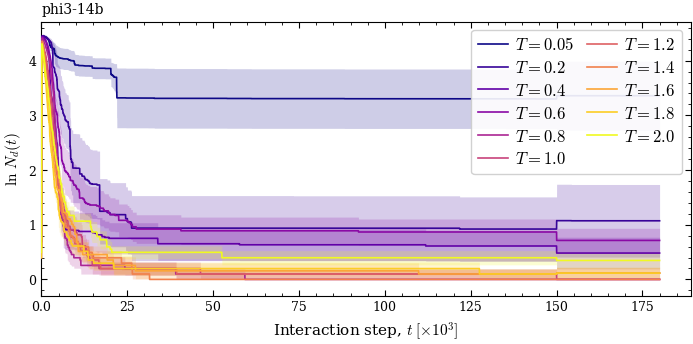

In [28]:

    FOLDER = 'results_ji'
    MODEL = 'phi3-14b'
    EXPERIMENT = 'na90-n12e4' #'na1p5e2-ns9e4' 

    temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] 
    all_seeds = [6,7,8,9,10,11,12] #[0,1,2,3,4,5,6,7]
    fig, ax = plot_nd_vs_steps(
        folder=FOLDER,
        model_name=MODEL,
        experiment=EXPERIMENT,
        seeds=all_seeds,
        list_of_temp=temps,
        deterministic_path=None,
        max_steps=180000,
        figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
        cmap_name='plasma',
        subsample=20,
        show_bands=True,
        band_type= 'sem', 
        band_alpha=0.2,
        use_colorbar=False,
        title=MODEL,
        output_path=None,
    )
    
    df_words_dng = pd.read_json("./results_ji/num_of_diff_words_na1p5e2_deterministic.json")
    #plt.plot(df_words_dng.index[:180000], np.log(df_words_dng['diff_word_count'][:180000]), label='Deterministic NG', color='black', linewidth=1.0)
    #plt.xlim(-1500,180000)
    fig.savefig(f'./paper-images/pdfs/{MODEL}_log-num-diff-words_vs_steps.pdf', bbox_inches='tight')
    fig.savefig(f'./paper-images/pngs/{MODEL}_log-num-diff-words_vs_steps.png', dpi=200)
    plt.show()

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


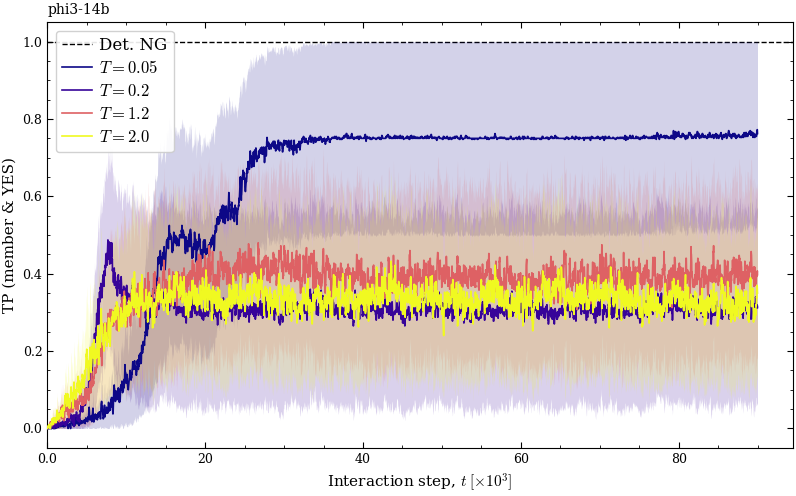

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


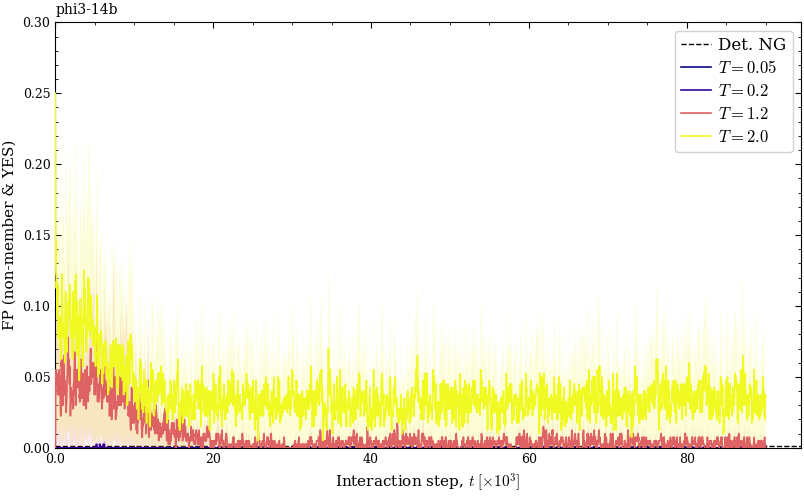

In [ ]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.3)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.png', dpi=200)
plt.show()


In [ ]:
### Put the plots in one raw 
"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))

plot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)

plot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)

fig.tight_layout(pad=0.3)
fig.savefig('fig_pi_phi_two_panel.pdf')
"""

"\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))\n\nplot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)\n\nplot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)\n\nfig.tight_layout(pad=0.3)\nfig.savefig('fig_pi_phi_two_panel.pdf')\n"

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


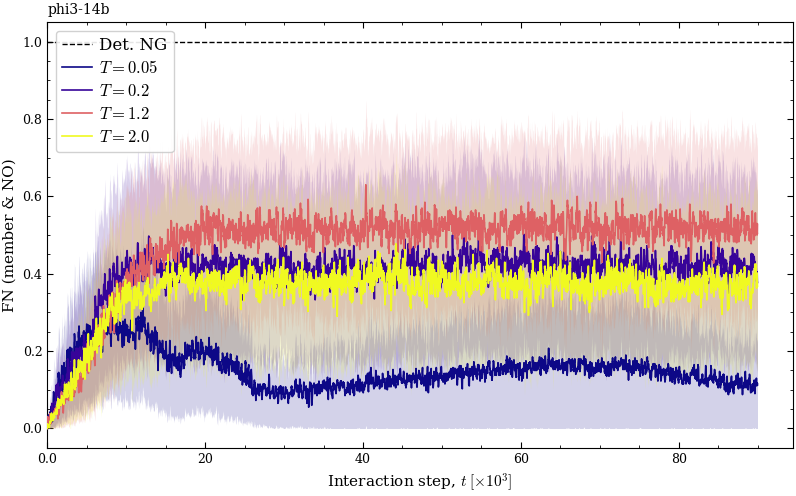

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


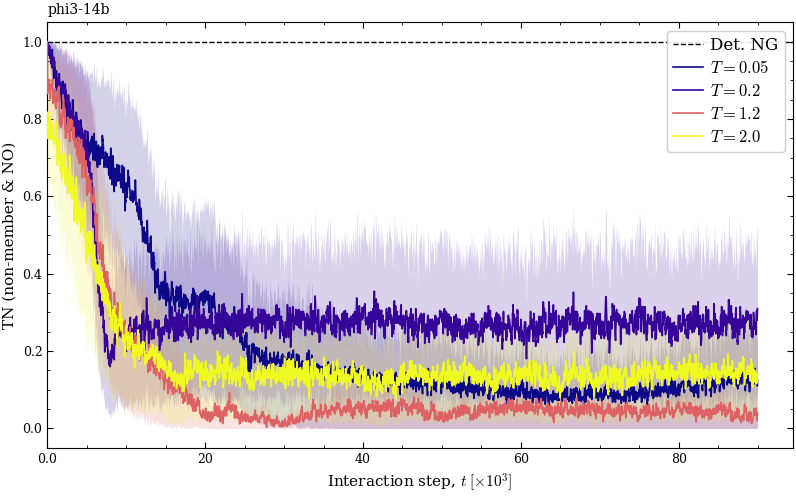

In [ ]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.png', dpi=200)
plt.show()

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


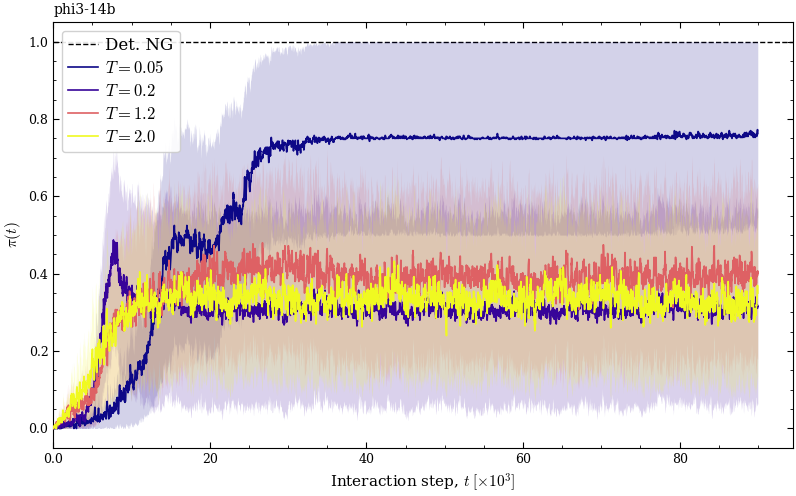

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


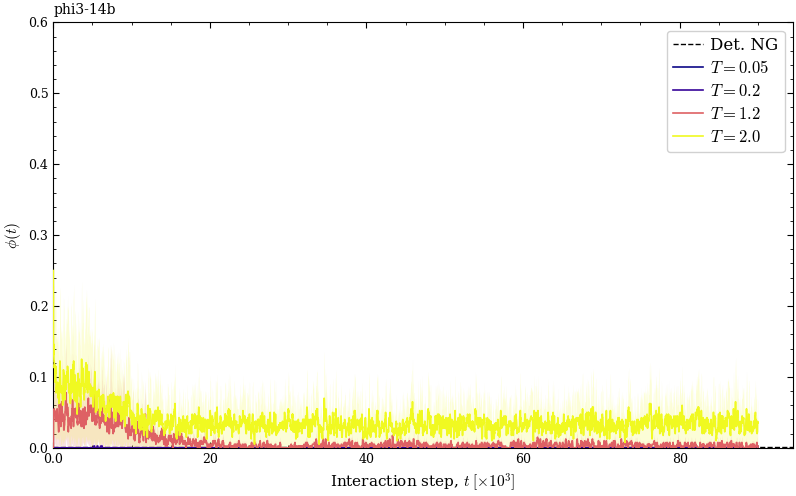

  T=0.05: 4 seed(s) loaded, 90000 steps
  T=0.2: 4 seed(s) loaded, 90000 steps
  T=1.2: 4 seed(s) loaded, 90000 steps
  T=2.0: 4 seed(s) loaded, 90000 steps


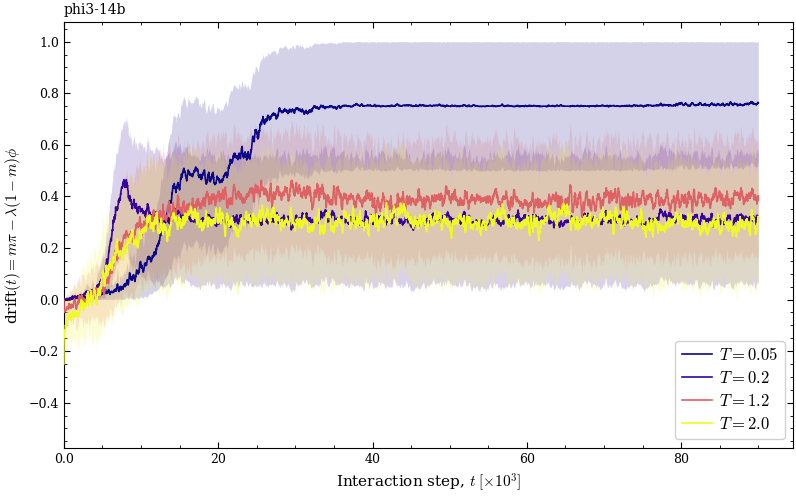

In [29]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_pi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_pi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.6)
fig.savefig(f'./paper-images/pdfs/{MODEL}_phi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_phi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='drift',
    model=MODEL,
    experiment='na1p5e2-ns9e4',
    seeds=[4, 5, 6, 7],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=200,
    subsample=20,
    use_colorbar=False,
    lam=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_drift_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_drift_vs_steps.png', dpi=200)
plt.show()


  N=50:
    → 11 temperatures, 4 fully converged, 6 partial   (median+iqr)
  N=70:
    → 11 temperatures, 3 fully converged, 8 partial   (median+iqr)
  N=90:
    → 11 temperatures, 2 fully converged, 9 partial   (median+iqr)
  N=110:
    → 11 temperatures, 0 fully converged, 11 partial   (median+iqr)
  N=150:
    → 11 temperatures, 0 fully converged, 11 partial   (median+iqr)
Saved → fig_tc_vs_T_phi3.pdf

  Exponential fit on log(median(t_c)) vs T
     N    alpha           A      R2  pts
  ----  -------  ----------  ------  ---
    50    0.102     4188.51   0.020   10
    70    0.731     3540.58   0.810   11
    90    0.207    10524.41   0.115   11
   110    0.779     8161.33   0.682   11
   150    0.321    17504.25   0.418   11
  ----  -------
  <alpha>    0.428 +/- 0.309


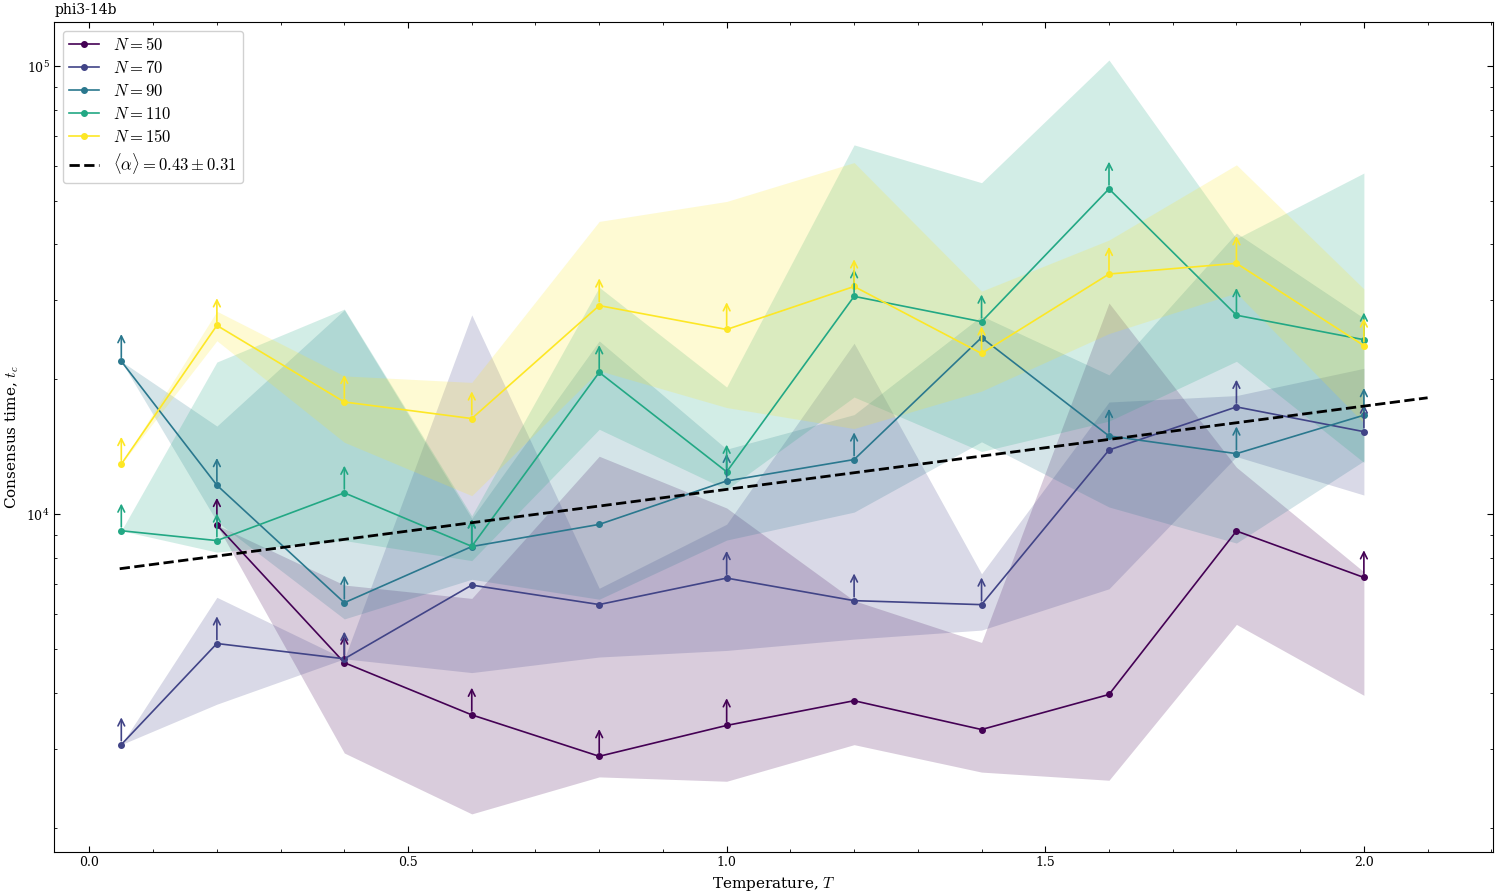

In [30]:

temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

configs = [
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na50-n8e4',
     'seeds': [0,1,2,3,4,5,6], 'N': 50},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na70-n8e4',
     'seeds': [0,1,2,3,4,5], 'N': 70},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na90-n12e4',
     'seeds': [6,7,8,9,10,11,12,13], 'N': 90},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na110-n12e4',
     'seeds': [10,11,12,13,14,15,16,17,18,19,20,21,22,23], 'N': 110},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na150-n15e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]


#13,14,15,16,17,18,19

fig, ax = plot_tc_vs_temperature(
    configs=configs,
    list_of_temp=temp_range,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='viridis',
    show_errorbars=True, error_style='band', band_alpha=0.2, band_type='iqr', 
    log_y=True,              # try True for log scale
    use_colorbar=False,        # colorbar for N, or False for legend
    title=MODEL,
    output_path='fig_tc_vs_T_phi3.pdf',
)

alphas, alpha_avg = overlay_alpha_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_N=False,
    show_average=True,
    )


fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.png', dpi=200)
plt.show()


  Temperature T=0.05:
    → 5 agent counts, 0 fully converged, 4 partial   (median+iqr)
  Temperature T=0.2:
    → 5 agent counts, 0 fully converged, 5 partial   (median+iqr)
  Temperature T=0.4:
    → 5 agent counts, 0 fully converged, 5 partial   (median+iqr)
  Temperature T=0.6:
    → 5 agent counts, 1 fully converged, 4 partial   (median+iqr)
  Temperature T=0.8:
    → 5 agent counts, 2 fully converged, 3 partial   (median+iqr)
  Temperature T=1.0:
    → 5 agent counts, 0 fully converged, 5 partial   (median+iqr)
  Temperature T=1.2:
    → 5 agent counts, 1 fully converged, 4 partial   (median+iqr)
  Temperature T=1.4:
    → 5 agent counts, 2 fully converged, 3 partial   (median+iqr)
  Temperature T=1.6:
    → 5 agent counts, 2 fully converged, 3 partial   (median+iqr)
  Temperature T=1.8:
    → 5 agent counts, 1 fully converged, 4 partial   (median+iqr)
  Temperature T=2.0:
    → 5 agent counts, 0 fully converged, 5 partial   (median+iqr)
Saved → fig_tc_vs_N_phi3.pdf

  Power-law 

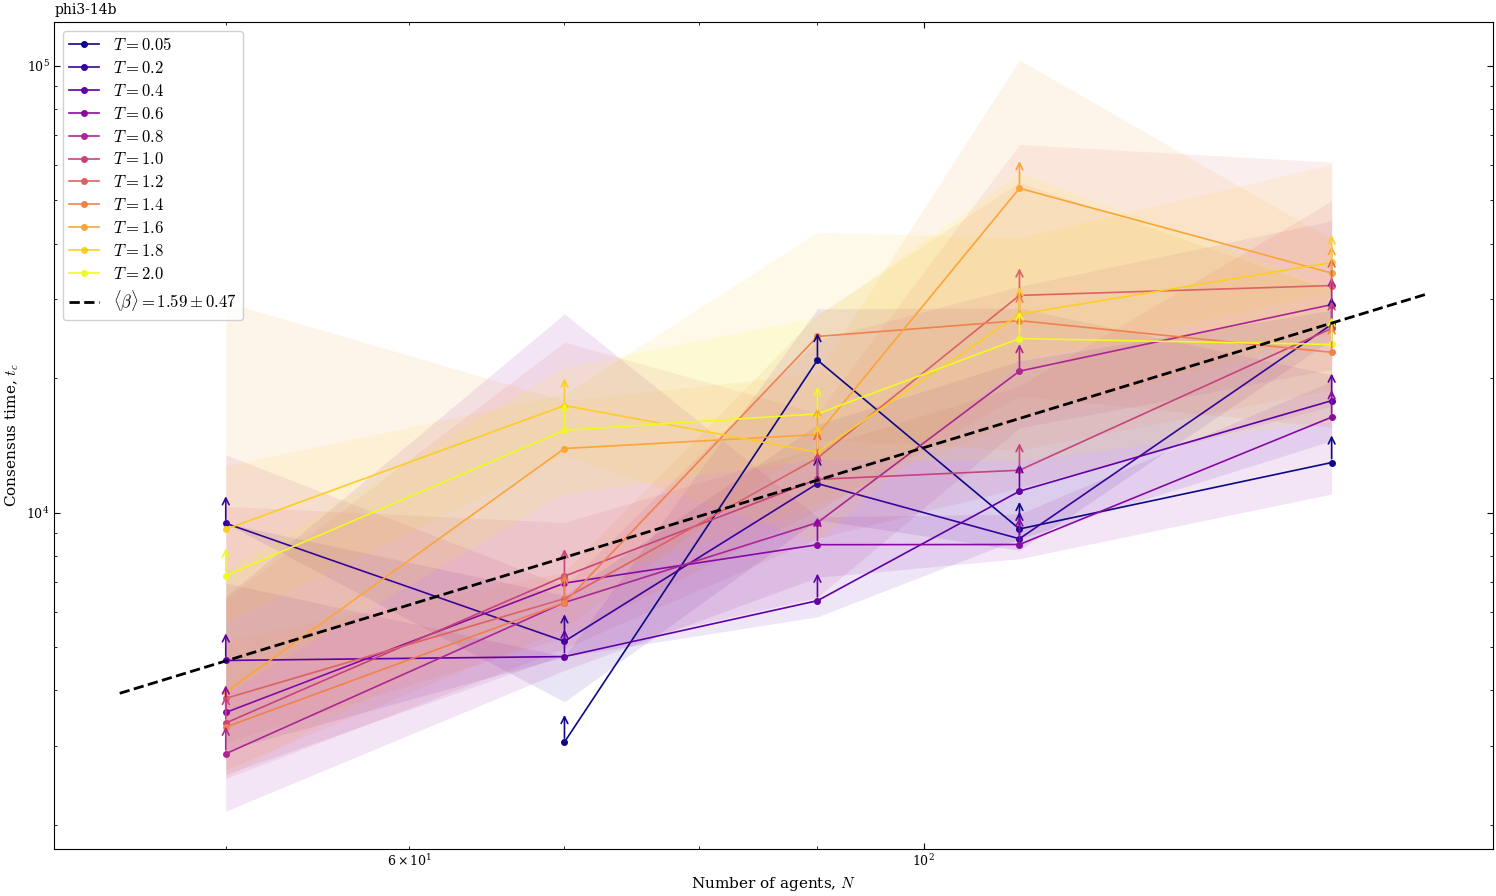

In [31]:
temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]


fig, ax = plot_tc_vs_agents(
    configs=configs,
    list_of_temp=temp_range,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='plasma',
    show_errorbars=True, error_style='band', band_alpha=0.1, band_type='iqr',
    use_colorbar=False,
    title=MODEL,
    log_x=True, 
    log_y=True,
    output_path='fig_tc_vs_N_phi3.pdf',
)

betas, beta_avg = overlay_beta_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_temp=False,    # thin colored dashed line per T
    show_average=True,     # thick dashed black <β> line
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.png', dpi=200)
plt.show()

Pallino vuoto: non tutti i seed raggiungono il consenso, ma la media di chi lo raggiunge è il pallino vuoto

## llama3.1:8b model

  T=0.05: 8 seed(s) loaded, 70000 steps
  T=0.2: 8 seed(s) loaded, 70000 steps
  T=0.4: 8 seed(s) loaded, 70000 steps
  T=0.6: 8 seed(s) loaded, 70000 steps
  T=0.8: 8 seed(s) loaded, 70000 steps
  T=1.0: 8 seed(s) loaded, 70000 steps
  T=1.2: 8 seed(s) loaded, 70000 steps
  T=1.4: 8 seed(s) loaded, 70000 steps
  T=1.6: 8 seed(s) loaded, 70000 steps
  T=1.8: 8 seed(s) loaded, 70000 steps
  T=2.0: 8 seed(s) loaded, 70000 steps
Saved → fig_Nd_vs_steps_colorbar.pdf


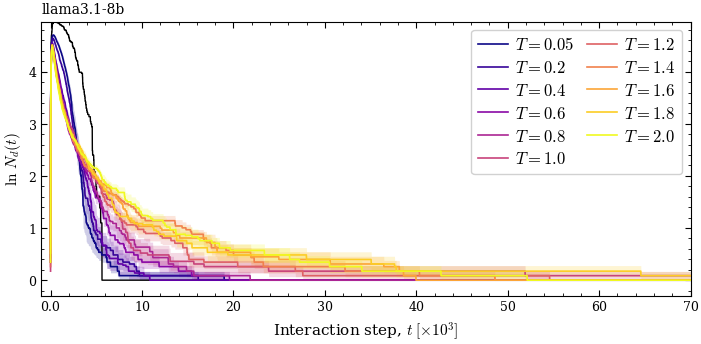

In [42]:

    FOLDER = 'results_ji'
    MODEL = 'llama3.1-8b'
    EXPERIMENT = 'na1p5e2-ns7e4' 

    temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] 
    all_seeds = [0,1,2,3,4,5,8,9]
    fig, ax = plot_nd_vs_steps(
        folder=FOLDER,
        model_name=MODEL,
        experiment=EXPERIMENT,
        seeds=all_seeds,
        list_of_temp=temps,
        deterministic_path=None,
        max_steps=70000,
        figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
        cmap_name='plasma',
        subsample=20,
        show_bands=True,
        band_type='sem', 
        band_alpha=0.2,
        use_colorbar=False,
        title=MODEL,
        output_path='fig_Nd_vs_steps_colorbar.pdf',
    )
    
    df_words_dng = pd.read_json("./results_ji/num_of_diff_words_na1p5e2_deterministic.json")
    plt.plot(df_words_dng.index[:70000], np.log(df_words_dng['diff_word_count'][:70000]), label='Deterministic NG', color='black', linewidth=1.0)
    fig.savefig(f'./paper-images/pdfs/{MODEL}_log-num-diff-words_vs_steps.pdf', bbox_inches='tight')
    fig.savefig(f'./paper-images/pngs/{MODEL}_log-num-diff-words_vs_steps.png', dpi=200)
    plt.xlim(-1000,70000)
    plt.show()

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


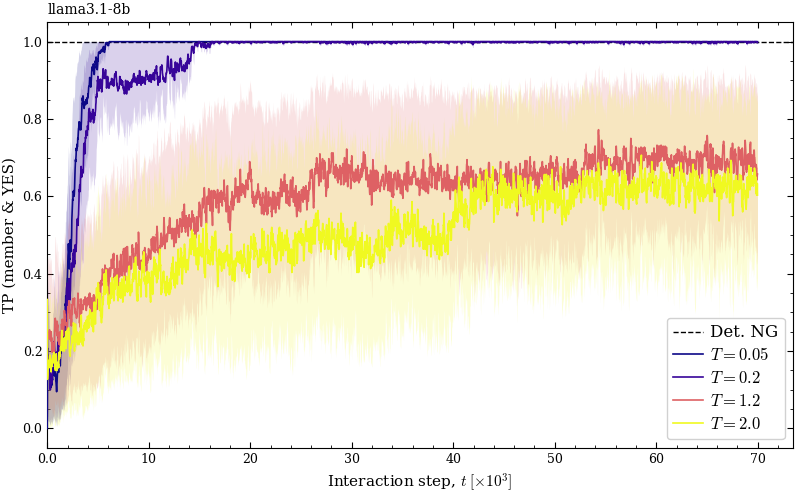

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


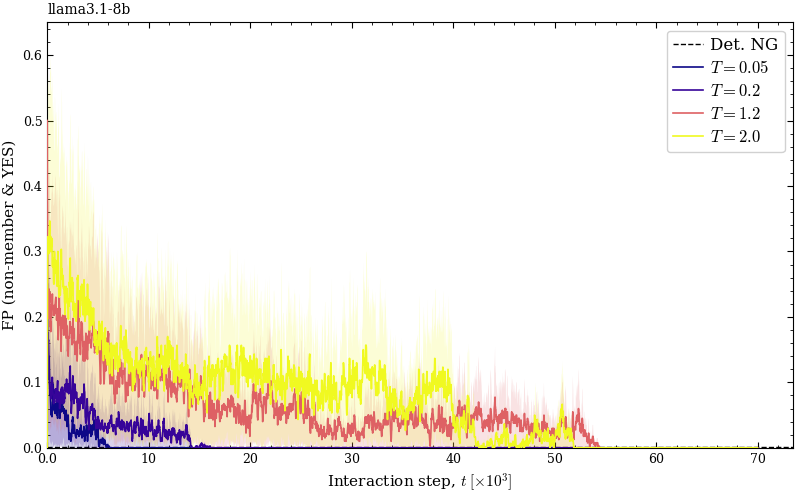

In [ ]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns7e4' ,
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns7e4' ,
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.65)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.png', dpi=200)
plt.show()


In [38]:
### Put the plots in one raw 
"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))

plot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)

plot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)

fig.tight_layout(pad=0.3)
fig.savefig('fig_pi_phi_two_panel.pdf')
"""

"\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))\n\nplot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)\n\nplot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)\n\nfig.tight_layout(pad=0.3)\nfig.savefig('fig_pi_phi_two_panel.pdf')\n"

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


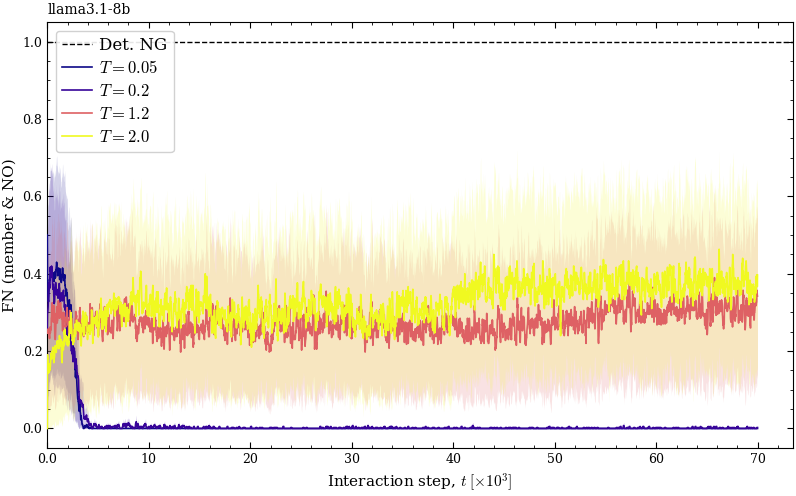

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


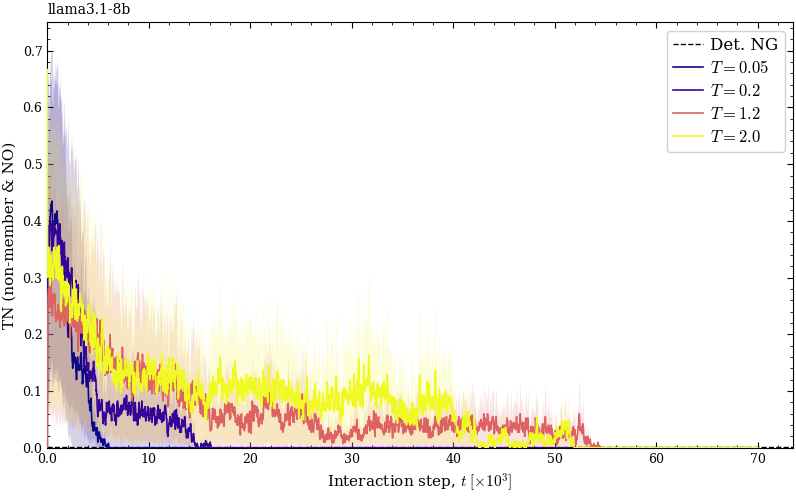

In [ ]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=70000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=90000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.75)
#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.png', dpi=200)
plt.show()

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


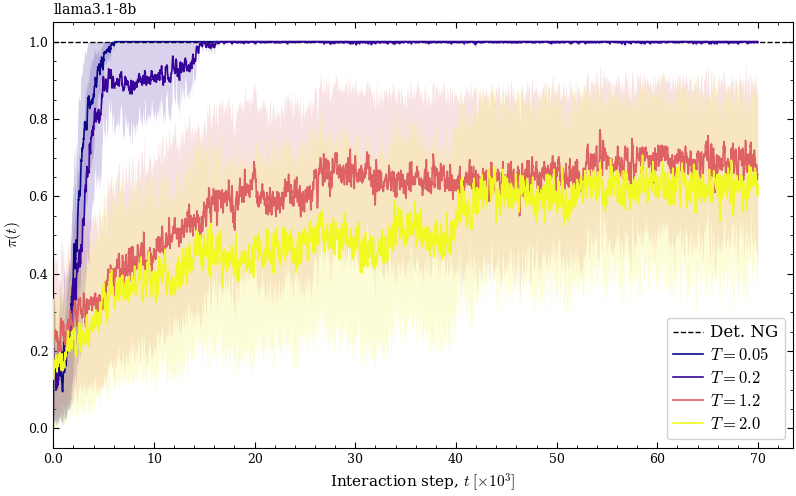

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


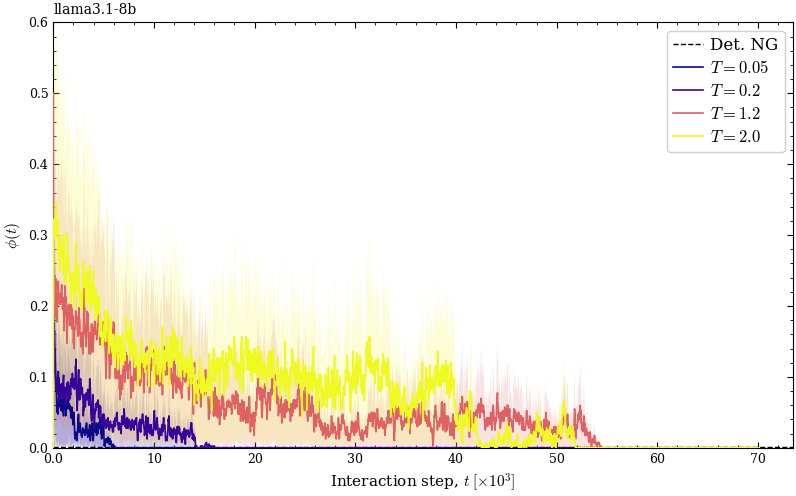

  T=0.05: 4 seed(s) loaded, 70000 steps
  T=0.2: 4 seed(s) loaded, 70000 steps
  T=1.2: 4 seed(s) loaded, 70000 steps
  T=2.0: 3 seed(s) loaded, 70000 steps


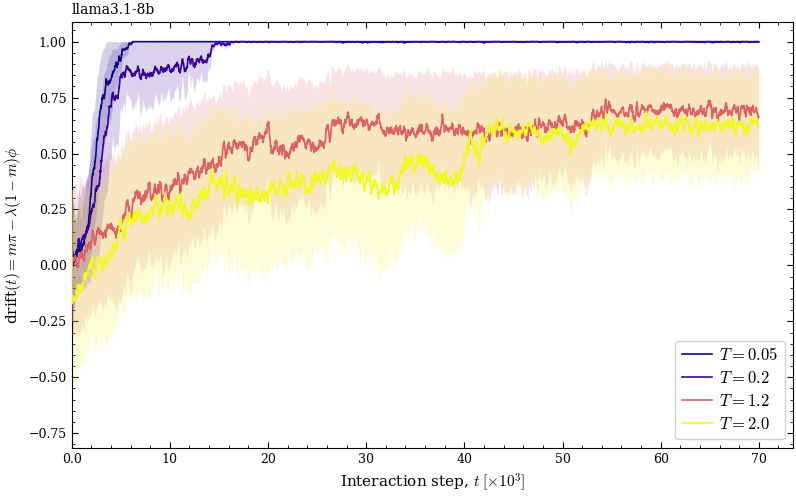

In [43]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=70000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_pi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_pi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=70000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.6)
fig.savefig(f'./paper-images/pdfs/{MODEL}_phi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_phi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='drift',
    model=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=70000,
    smooth_rolling=200,
    subsample=20,
    use_colorbar=False,
    lam=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_drift_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_drift_vs_steps.png', dpi=200)
plt.show()


  N=50:
    → 11 temperatures, 11 fully converged, 0 partial   (median+iqr)
  N=70:
    → 11 temperatures, 11 fully converged, 0 partial   (median+iqr)
  N=90:
    → 11 temperatures, 10 fully converged, 1 partial   (median+iqr)
  N=110:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr)
  N=150:
    → 11 temperatures, 8 fully converged, 3 partial   (median+iqr)
Saved → fig_tc_vs_T_phi3.pdf

  Exponential fit on log(median(t_c)) vs T
     N    alpha           A      R2  pts
  ----  -------  ----------  ------  ---
    50    0.627     1378.51   0.734   11
    70    0.465     2433.51   0.663   11
    90    0.640     3038.90   0.788   11
   110    0.752     4092.09   0.867   11
   150    0.845     5495.46   0.901   11
  ----  -------
  <alpha>    0.666 +/- 0.143


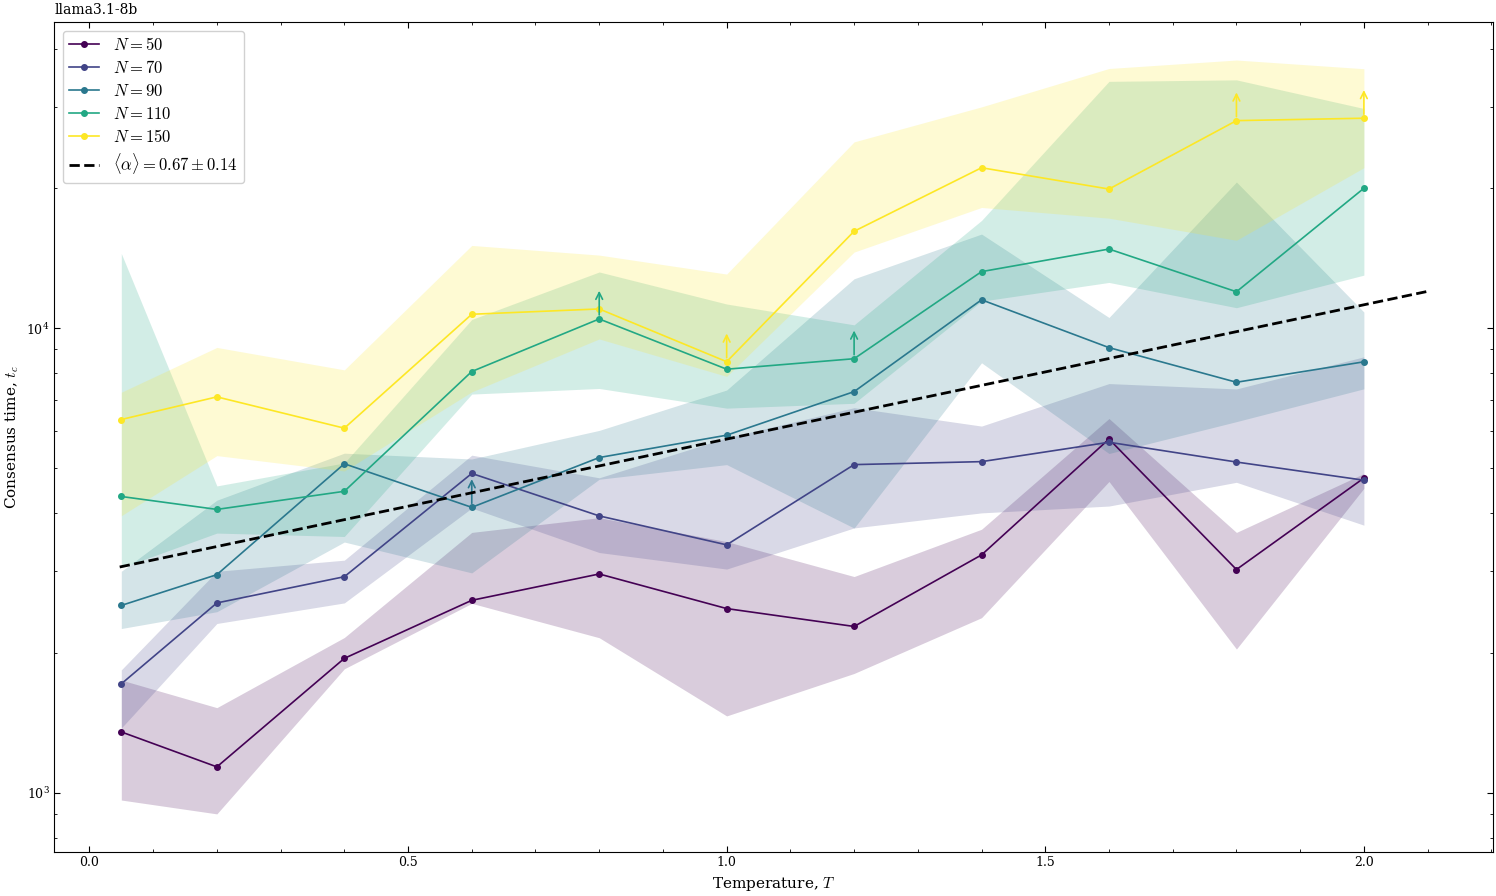

In [33]:


temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

configs = [
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na50-n7e4',
     'seeds': [0,1,2,4,5,6], 'N': 50},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na70-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 70},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na90-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 90},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na110-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 110},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na1p5e2-ns7e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]

fig, ax = plot_tc_vs_temperature(
    configs=configs,
    list_of_temp=temp_range,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='viridis',
    show_errorbars=True, error_style='band', band_alpha=0.2, band_type='iqr',
    log_y=True,              # try True for log scale
    use_colorbar=False,        # colorbar for N, or False for legend
    title=MODEL,
    output_path='fig_tc_vs_T_phi3.pdf',
)

alphas, alpha_avg = overlay_alpha_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_N=False,
    show_average=True,
    )

fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.png', dpi=200)
plt.show()

  Temperature T=0.05:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=0.2:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=0.4:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=0.6:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=0.8:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=1.0:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=1.2:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=1.4:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=1.6:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=1.8:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=2.0:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
Saved → fig_tc_vs_N_demo.pdf

  Power-law 

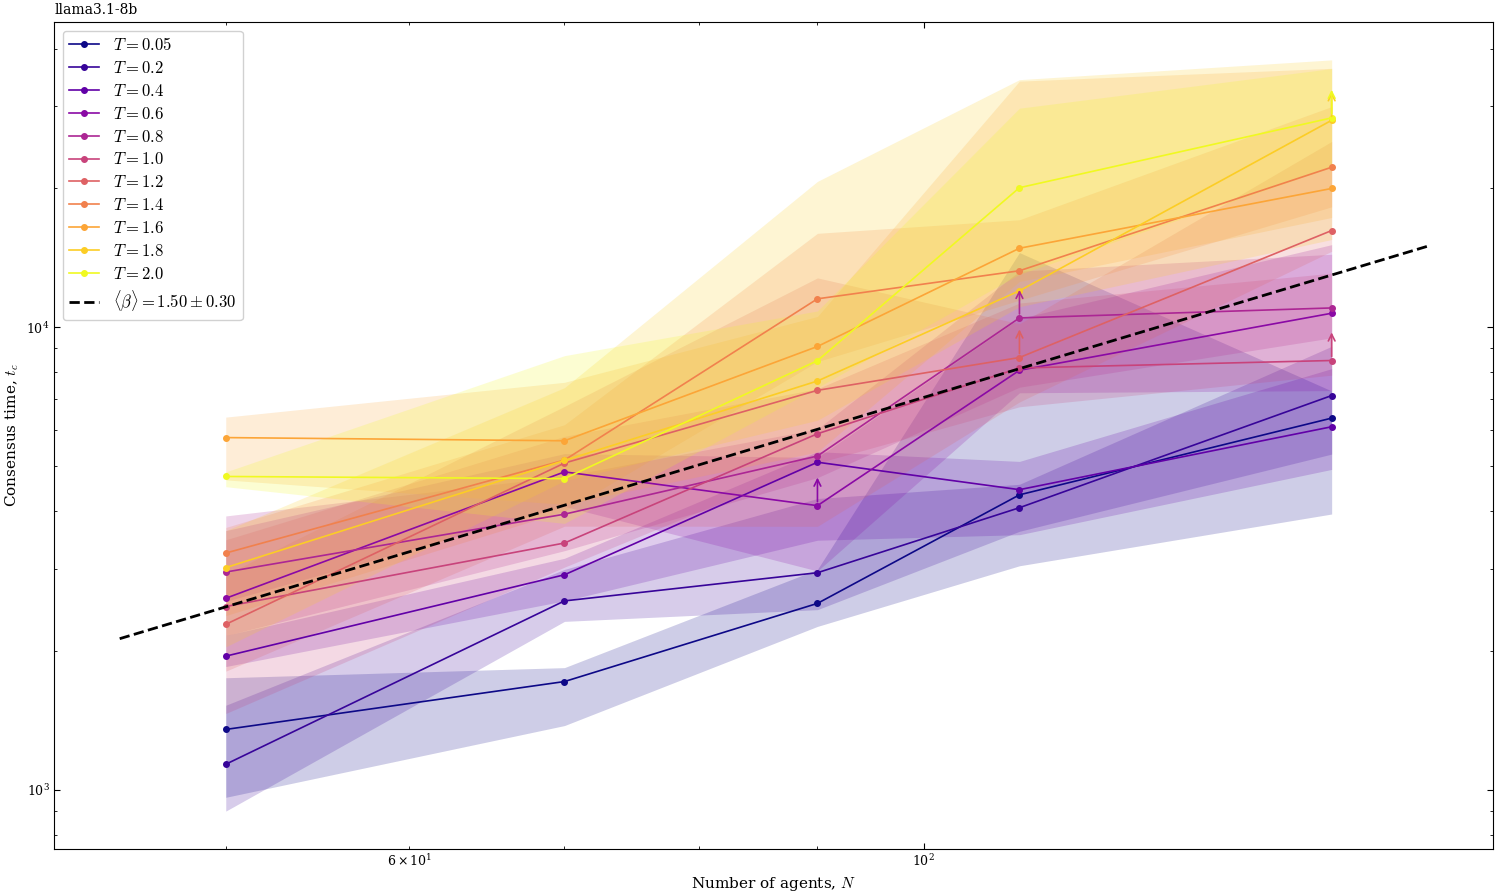

In [34]:

temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

configs = [
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na50-n7e4',
     'seeds': [0,1,2,4,5,6], 'N': 50},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na70-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 70},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na90-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 90},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na110-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 110},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na1p5e2-ns7e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]


fig, ax = plot_tc_vs_agents(
    configs=configs,
    list_of_temp=temp_range,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='plasma',
    show_errorbars=True, error_style='band', band_alpha=0.2, band_type='iqr',
    use_colorbar=False,
    title=MODEL,
    log_x=True, 
    log_y=True,
    output_path='fig_tc_vs_N_demo.pdf',
)

betas, beta_avg = overlay_beta_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_temp=False,    # thin colored dashed line per T
    show_average=True,    # thick dashed black <β> line
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.png', dpi=200)
plt.show()

## mistral-7b model

  T=0.05: 15 seed(s) loaded, lengths 35000–70000 steps (padded with NaN)
  T=0.2: 15 seed(s) loaded, 35000 steps
  T=0.4: 15 seed(s) loaded, 35000 steps
  T=0.6: 15 seed(s) loaded, 35000 steps
  T=0.8: 15 seed(s) loaded, 35000 steps
  T=1.0: 15 seed(s) loaded, 35000 steps
  T=1.2: 15 seed(s) loaded, 35000 steps
  T=1.4: 15 seed(s) loaded, 35000 steps
  T=1.6: 15 seed(s) loaded, 35000 steps
  T=1.8: 15 seed(s) loaded, 35000 steps
  T=2.0: 15 seed(s) loaded, 35000 steps
Saved → fig_Nd_vs_steps_colorbar.pdf


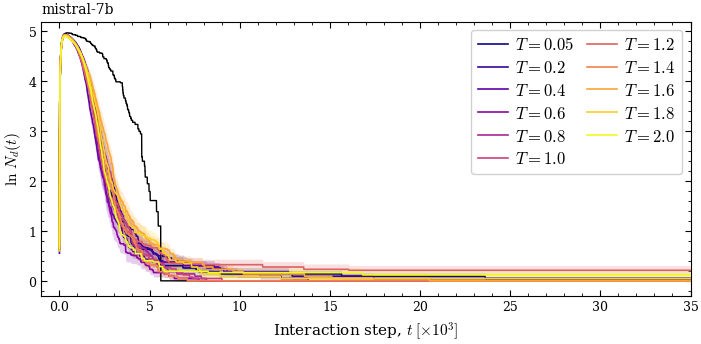

In [35]:

    FOLDER = 'results_ji'
    MODEL = 'mistral-7b'
    EXPERIMENT = 'na1p5e2-ns11e4'  

    temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] 
    all_seeds = [0,1,2,3,50,51,53,54,55,56,57,58,59,60,61]
    fig, ax = plot_nd_vs_steps(
        folder=FOLDER,
        model_name=MODEL,
        experiment=EXPERIMENT,
        seeds=all_seeds,
        list_of_temp=temps,
        deterministic_path=None,
        max_steps=35000,
        figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
        cmap_name='plasma',
        subsample=20,
        show_bands=True,
        band_type='sem', 
        band_alpha=0.2,
        use_colorbar=False,
        title=MODEL,
        output_path='fig_Nd_vs_steps_colorbar.pdf',
    )
    
    df_words_dng = pd.read_json("./results_ji/num_of_diff_words_na1p5e2_deterministic.json")
    plt.plot(df_words_dng.index[:35000], np.log(df_words_dng['diff_word_count'][:35000]), label='Deterministic NG', color='black', linewidth=1.0)
    fig.savefig(f'./paper-images/pdfs/{MODEL}_log-num-diff-words_vs_steps.pdf', bbox_inches='tight')
    fig.savefig(f'./paper-images/pngs/{MODEL}_log-num-diff-words_vs_steps.png', dpi=200)
    plt.xlim(-1000,35000)
    plt.show()

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


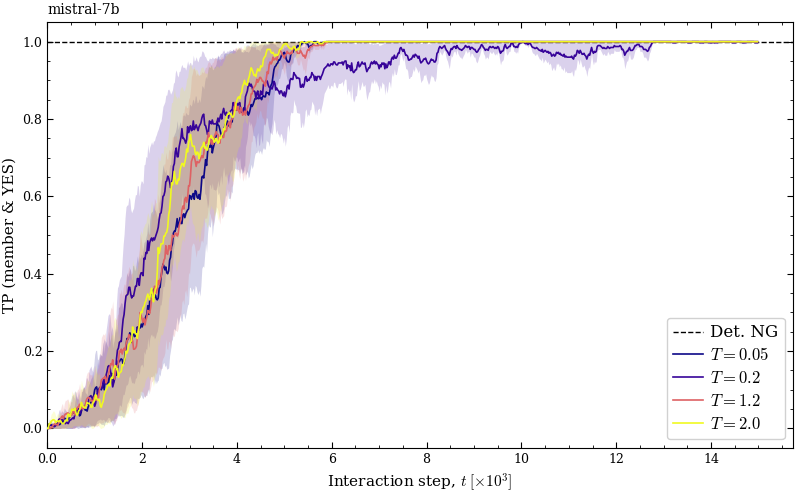

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


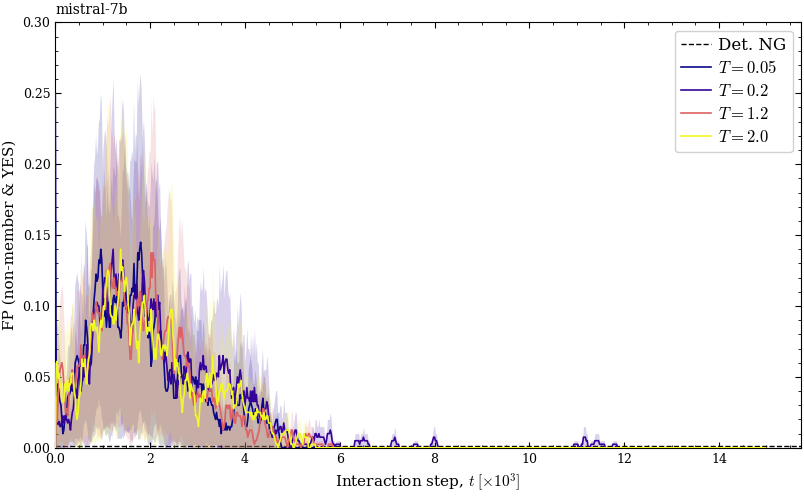

In [14]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns11e4' ,
    seeds=[58,59,60,61],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-yes_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='yes',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns11e4' ,
    seeds=[58,59,60,61],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.3)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-yes_vs_steps.png', dpi=200)
plt.show()


In [ ]:
### Put the plots in one raw 
"""
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))

plot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)

plot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],
               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',
               data_dir='./pi_and_phi', max_steps=90000,
               smooth_rolling=100, subsample=20,
               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)

fig.tight_layout(pad=0.3)
fig.savefig('fig_pi_phi_two_panel.pdf')
"""

"\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.38))\n\nplot_pi_or_phi('pi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=1.0, title='(a)', ax=ax1)\n\nplot_pi_or_phi('phi', 'phi3-14b', 'na1p5e2-ns9e4', [4,5,6,7],\n               [0.05, 0.2, 0.6, 1.0, 2.0], response='yes',\n               data_dir='./pi_and_phi', max_steps=90000,\n               smooth_rolling=100, subsample=20,\n               use_colorbar=False, det_value=0.0, title='(b)', ax=ax2)\n\nfig.tight_layout(pad=0.3)\nfig.savefig('fig_pi_phi_two_panel.pdf')\n"

  T=0.05: 5 seed(s) loaded, 120000 steps
  T=0.2: 5 seed(s) loaded, 120000 steps
  T=1.2: 5 seed(s) loaded, 120000 steps
  T=2.0: 5 seed(s) loaded, 120000 steps


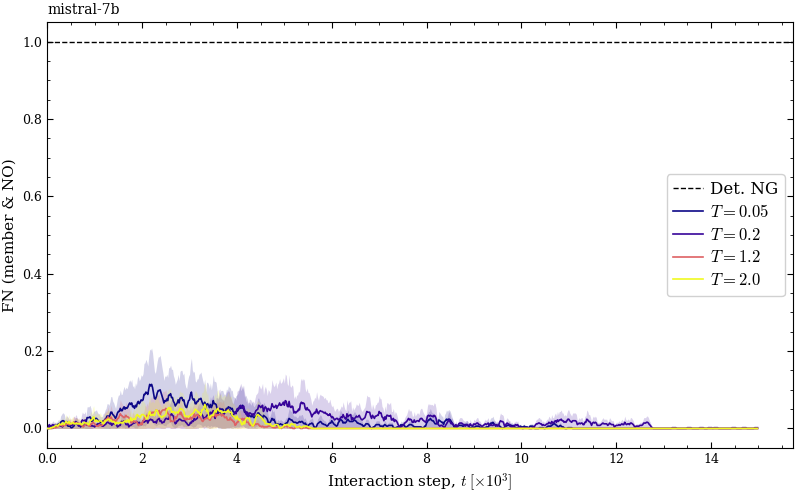

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


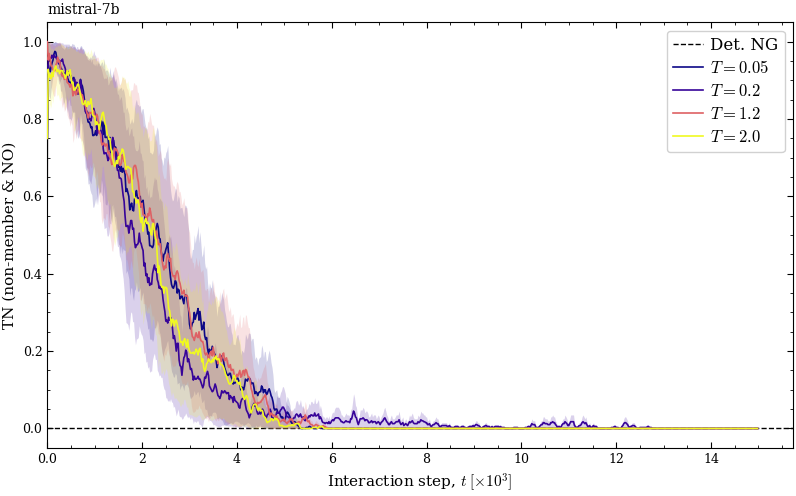

In [15]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns11e4',
    seeds=[58,59,60,61,9,10,11,12,6,7,8],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_pi-no_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='no',              # ← TP events
    model=MODEL,
    experiment='na1p5e2-ns11e4',
    seeds=[58,59,60,61],
    list_of_temp= [0.05, 0.2, 1.2, 2.0], #[0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.pdf', dpi=200)
#fig.savefig(f'./paper-images/{MODEL}_phi-no_vs_steps.png', dpi=200)
plt.show()

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


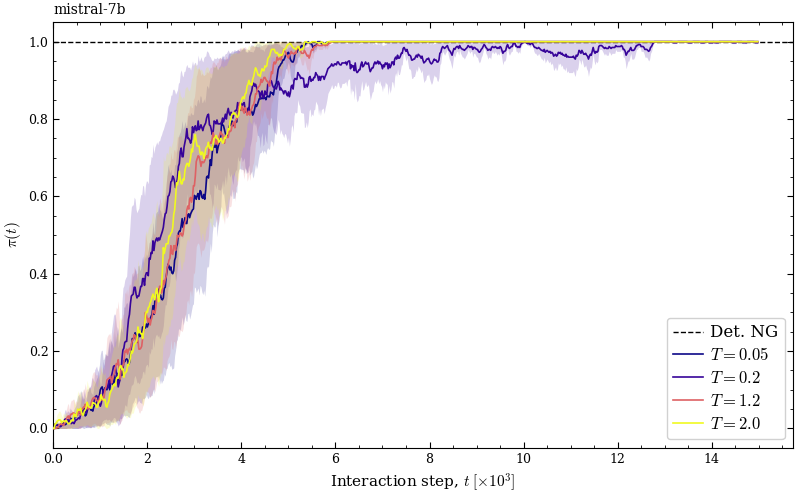

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


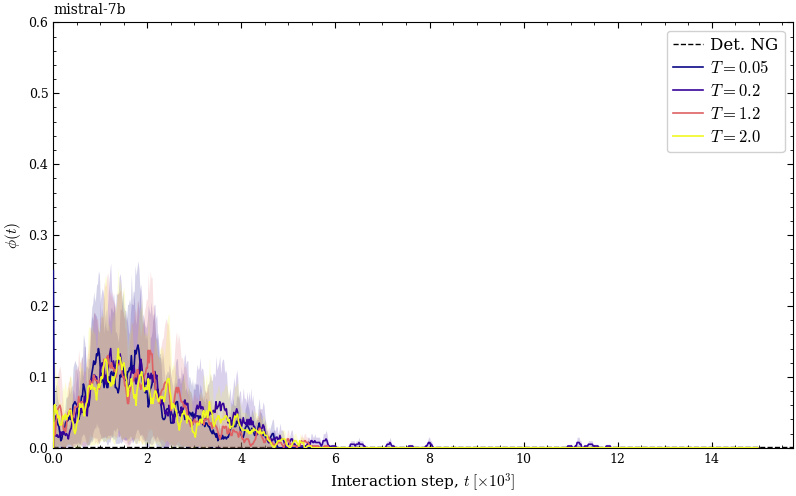

  T=0.05: 4 seed(s) loaded, 35000 steps
  T=0.2: 4 seed(s) loaded, 35000 steps
  T=1.2: 4 seed(s) loaded, 35000 steps
  T=2.0: 4 seed(s) loaded, 35000 steps


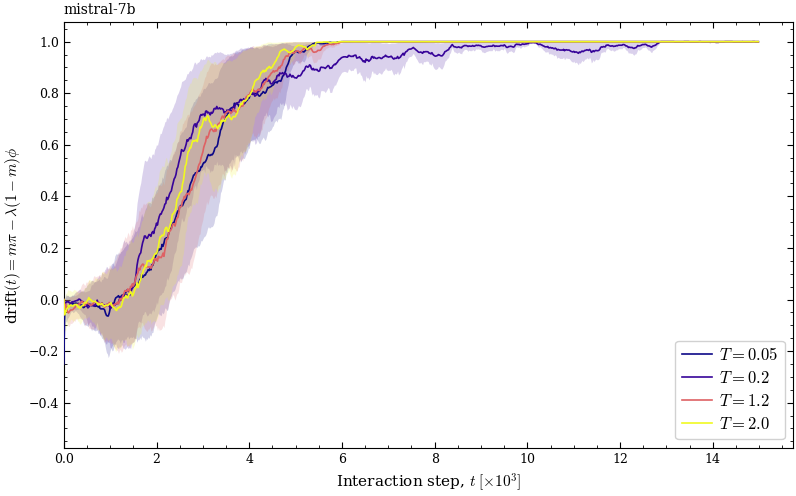

In [36]:
fig, ax = plot_pi_or_phi(
    quantity='pi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns11e4',
    seeds=[58,59,60,61],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_pi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_pi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='phi',
    response='ratio',            # ← computed probability
    model=MODEL,
    experiment='na1p5e2-ns11e4',
    seeds=[58,59,60,61],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=100,
    subsample=20,
    use_colorbar=False,
    det_value=0.001,
    title=MODEL,
    figsize=(8, 5),
)

plt.ylim(0,0.6)
fig.savefig(f'./paper-images/pdfs/{MODEL}_phi-ratio_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_phi-ratio_vs_steps.png', dpi=200)
plt.show()

fig, ax = plot_pi_or_phi(
    quantity='drift',
    model=MODEL,
    experiment='na1p5e2-ns11e4',
    seeds=[58,59,60,61],
    list_of_temp=[0.05, 0.2, 1.2, 2.0],
    data_dir='./pi_and_phi',
    max_steps=15000,
    smooth_rolling=200,
    subsample=20,
    use_colorbar=False,
    lam=1.0,
    title=MODEL,
    figsize=(8, 5),
)

fig.savefig(f'./paper-images/pdfs/{MODEL}_drift_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_drift_vs_steps.png', dpi=200)
plt.show()


  N=50:
    → 11 temperatures, 8 fully converged, 3 partial   (median+iqr)
  N=70:
    → 11 temperatures, 8 fully converged, 3 partial   (median+iqr)
  N=90:
    → 11 temperatures, 7 fully converged, 4 partial   (median+iqr)
  N=110:
    → 11 temperatures, 7 fully converged, 4 partial   (median+iqr)
  N=150:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr)
Saved → fig_tc_vs_T_phi3.pdf

  Exponential fit on log(median(t_c)) vs T
     N    alpha           A      R2  pts
  ----  -------  ----------  ------  ---
    50   -0.001     1236.74   0.000   11
    70    0.001     1761.62   0.000   11
    90   -0.013     2606.46   0.006   11
   110    0.043     2977.43   0.048   11
   150    0.031     4917.85   0.018   11
  ----  -------
  <alpha>    0.012 +/- 0.024


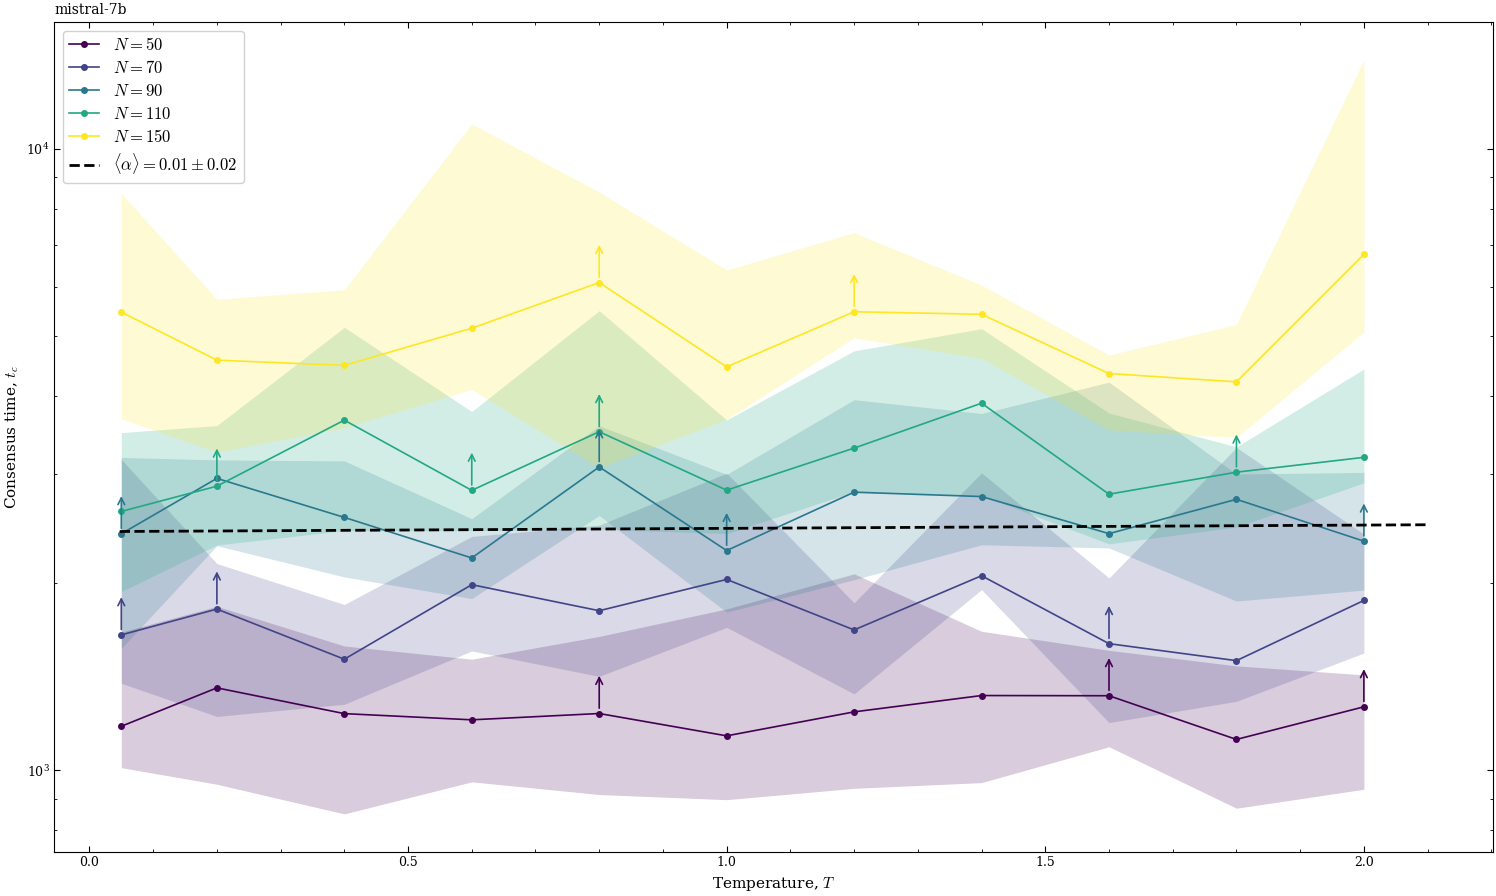

In [37]:


temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] #0.5


configs = [
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na50-n5e4',
     'seeds': [0,1,2,4,5,6,7,8,9,10,11,12], 'N': 50},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na70-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12], 'N': 70},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na90-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12], 'N': 90},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na110-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16], 'N': 110},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na150-n9e4',
     'seeds': [6,7,8,9,10,11,12,13,14,15], 'N': 150},
    #{'folder': 'results_ji', 'model': MODEL, 'experiment': 'na1p5e2-ns11e4',
    #'seeds': [0,1,2,3], 'N': 150},
]

configs = [
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na50-n5e4',
     'seeds': [0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28], 'N': 50},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na70-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16], 'N': 70},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na90-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12], 'N': 90},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na110-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16], 'N': 110},
    {'folder': 'results_ji', 'model': MODEL, 'experiment': 'na150-n9e4',
     'seeds': [6,7,8,9,10,11,12,13,14,15], 'N': 150},
    #{'folder': 'results_ji', 'model': MODEL, 'experiment': 'na1p5e2-ns11e4',
    #'seeds': [0,1,2,3], 'N': 150},
]

fig, ax = plot_tc_vs_temperature(
    configs=configs,
    list_of_temp=temp_range,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='viridis',
    show_errorbars=True, error_style='band', band_alpha=0.2, band_type='iqr',
    log_y=True,              # try True for log scale
    use_colorbar=False,        # colorbar for N, or False for legend
    title=MODEL,
    output_path='fig_tc_vs_T_phi3.pdf',
)

alphas, alpha_avg = overlay_alpha_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_N=False,
    show_average=True,
    )

fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_temperatures_for-diff-num-of-agents.png', dpi=200)
plt.show()

  Temperature T=0.05:
    → 5 agent counts, 3 fully converged, 2 partial   (median+iqr)
  Temperature T=0.2:
    → 5 agent counts, 3 fully converged, 2 partial   (median+iqr)
  Temperature T=0.4:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=0.6:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=0.8:
    → 5 agent counts, 1 fully converged, 4 partial   (median+iqr)
  Temperature T=1.0:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=1.2:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=1.4:
    → 5 agent counts, 5 fully converged, 0 partial   (median+iqr)
  Temperature T=1.6:
    → 5 agent counts, 3 fully converged, 2 partial   (median+iqr)
  Temperature T=1.8:
    → 5 agent counts, 4 fully converged, 1 partial   (median+iqr)
  Temperature T=2.0:
    → 5 agent counts, 3 fully converged, 2 partial   (median+iqr)
Saved → fig_tc_vs_N_demo.pdf

  Power-law 

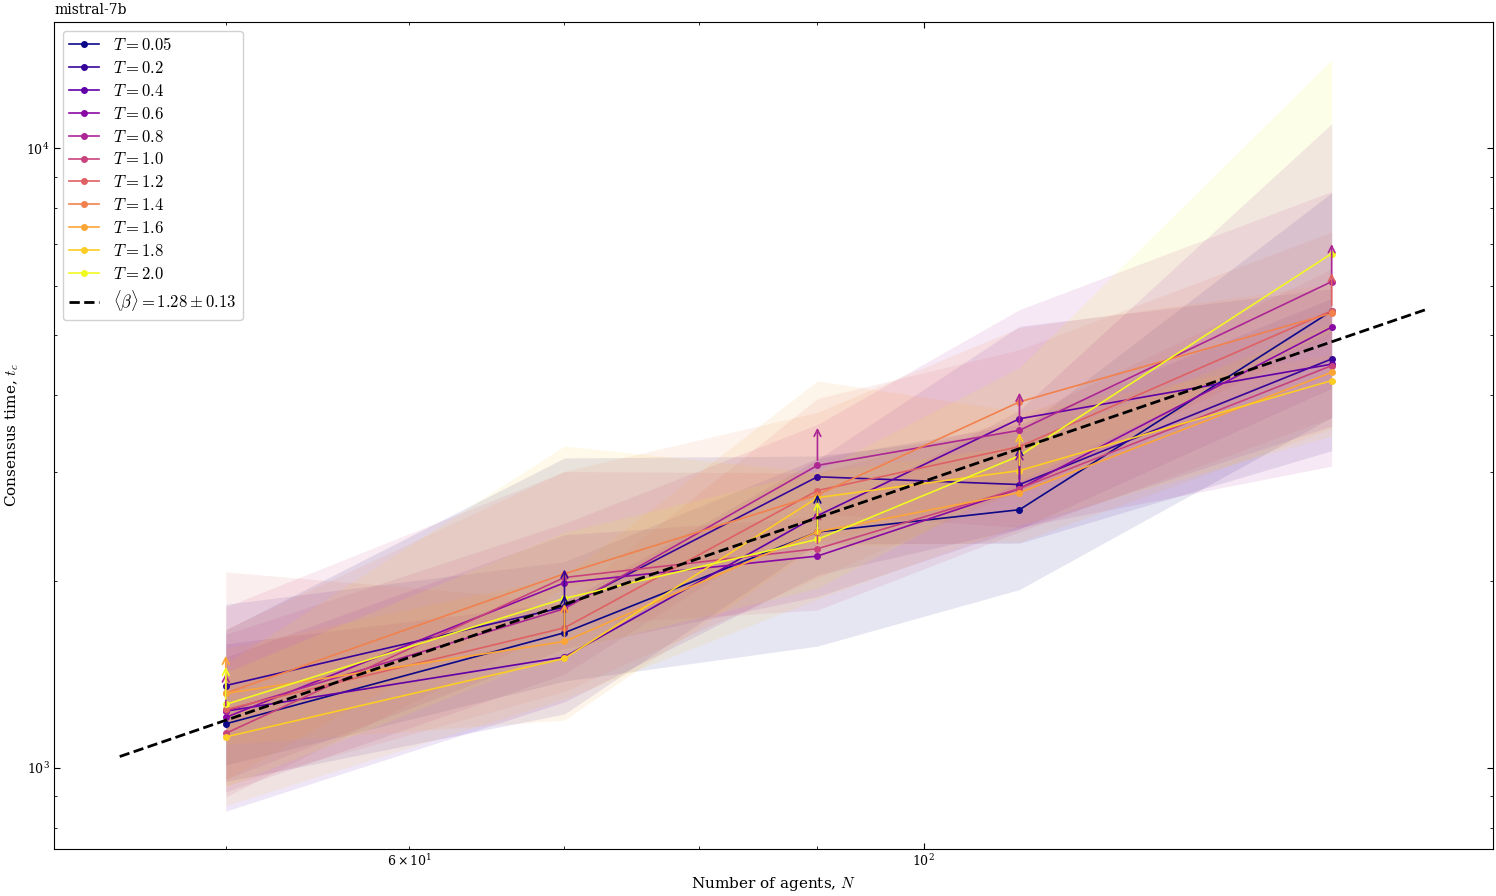

In [38]:

temp_range = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0] #0.5


fig, ax = plot_tc_vs_agents(
    configs=configs,
    list_of_temp=temps,
    criterion='equal_zero', #'less_than_log2',
    figsize=(15,9),#(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    cmap_name='plasma',
    show_errorbars=True, error_style='band', band_alpha=0.1, band_type='iqr',
    use_colorbar=False,
    title=MODEL,
    log_x=True, 
    log_y=True,
    output_path='fig_tc_vs_N_demo.pdf',
)

betas, beta_avg = overlay_beta_fits(
    ax, configs, temp_range,
    cmap_name='plasma',
    criterion='equal_zero',
    show_per_temp=False,    # thin colored dashed line per T
    show_average=True,     # thick dashed black <β> line
)

#import math
#plt.plot([50,70,90,110,150], [2*math.pow(x, 1.5) for x in [50,70,90,110,150]] , label=f'N**1.5', color="black", linestyle="--", linewidth=3.0)
fig.savefig(f'./paper-images/pdfs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_time-to-consensus_vs_num-of-agents_for-diff-temperatures.png', dpi=200)
plt.show()

### Outdated (not used plots)

  N=150, model=llama3.1-8b:
    → 11 temperatures, 8 fully converged, 3 partial   (median+iqr)
  N=150, model=mistral-7b:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr)
  N=150, model=phi3-14b:
    → 11 temperatures, 0 fully converged, 11 partial   (median+iqr)


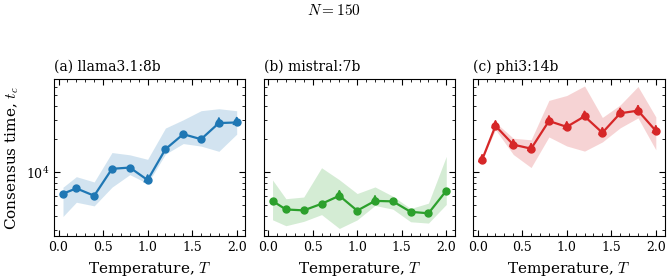

In [ ]:
# ── t_c vs Temperature at fixed N (single curve per panel) ─────────────
def plot_tc_vs_T_at_fixed_N(
    configs: list,                   # list of dicts, same format as plot_tc_vs_agents
    list_of_temp: list,
    criterion: str = 'equal_zero',
    figsize: tuple = None,
    color: str = 'C0',               # single colour for the curve
    log_x: bool = False,
    log_y: bool = True,
    show_errorbars: bool = True,
    error_style: str = 'band',       # 'bars' or 'band'
    band_type: str = 'iqr',          # 'iqr' (default), 'sem', or 'std'
    band_alpha: float = 0.20,
    marker_style: str = 'o',
    marker_size: float = 5,
    capsize: float = 3,
    mark_partial: bool = True,
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
    label: str = None,
):
    """
    Plot consensus time t_c vs temperature T for ONE model at ONE fixed N.

    Designed to be called three times to build a 1x3 figure
    (one panel per model) showing the architecture-dependent T-response.

    Parameters
    ----------
    configs : list of dicts (same format as plot_tc_vs_agents).
        Expected to contain a SINGLE element with keys
            'folder', 'model', 'experiment', 'seeds', 'N'
        Example:
            cfg_phi_150 = [
                {'folder': 'results_ji', 'model': 'phi3:14b',
                 'experiment': 'na150-n15e4',
                 'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
            ]
        If multiple dicts are passed, only the first is used (with a warning).
    list_of_temp : list of temperatures to plot on the x-axis
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'
    color : single colour for the curve
    log_y : log y-axis (default True). Recommended for cross-panel comparison.
    band_type :
        'iqr'  : central = median, band/bars = interquartile range [default]
        'sem'  : central = mean,   band/bars = mean ± std/sqrt(n)
        'std'  : central = mean,   band/bars = mean ± std
    show_errorbars : show error bars/band
    error_style : 'bars' or 'band'
    mark_partial : annotate points where some seeds did not converge
    title : panel title (e.g. '(a) llama3.1:8b')
    ax : existing Axes (for multi-panel figures). If None, creates a new figure.
    label : optional legend label
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if band_type not in ('iqr', 'sem', 'std'):
        raise ValueError(f"band_type must be 'iqr', 'sem', or 'std', got {band_type!r}")

    # Accept the user's list-of-dicts format. For a fixed-N plot we use
    # the first element. If there are several, warn and use the first.
    if not isinstance(configs, list) or len(configs) == 0:
        raise ValueError("configs must be a non-empty list of dicts (e.g. cfg_phi_150)")
    if len(configs) > 1:
        print(f"  Warning: {len(configs)} configs passed, using only the first "
              f"(N={configs[0]['N']}).")
    config = configs[0]

    N = config['N']
    stat_label = 'median' if band_type == 'iqr' else 'mean'

    # ── Loop over temperatures, computing the central tendency + band ───
    tc_T, tc_center, tc_lower, tc_upper, tc_nvalid, has_none_list = [], [], [], [], [], []

    print(f"  N={N}, model={config['model']}:")
    for temp in sorted(list_of_temp):
        tc_list = _consensus_times_per_seed(
            config['folder'], config['model'], config['experiment'],
            config['seeds'], temp, criterion)
        if not tc_list:
            continue
        none_count = tc_list.count(None)
        valid = [t for t in tc_list if t is not None]
        if not valid:
            tc_T.append(temp)
            tc_center.append(np.nan)
            tc_lower.append(np.nan)
            tc_upper.append(np.nan)
            tc_nvalid.append(0)
            has_none_list.append(True)
            continue

        v = np.asarray(valid, dtype=float)

        if band_type == 'iqr':
            c  = np.median(v)
            lo = np.percentile(v, 25) if len(v) >= 2 else v[0]
            hi = np.percentile(v, 75) if len(v) >= 2 else v[0]
        else:
            c  = np.mean(v)
            sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
            if band_type == 'sem':
                sd = sd / np.sqrt(len(v))
            lo = c - sd
            hi = c + sd

        tc_T.append(temp)
        tc_center.append(c)
        tc_lower.append(lo)
        tc_upper.append(hi)
        tc_nvalid.append(len(v))
        has_none_list.append(none_count > 0)

    if not tc_T:
        print(f"    No data for N={N}")
        if own_fig:
            return fig, ax
        return None, ax

    x        = np.array(tc_T, dtype=float)
    y        = np.array(tc_center)
    y_lo     = np.array(tc_lower)
    y_hi     = np.array(tc_upper)
    has_none = np.array(has_none_list)

    yerr_lo = y - y_lo
    yerr_hi = y_hi - y

    all_valid = ~np.isnan(y)
    converged = ~has_none & all_valid
    partial   = has_none & all_valid

    print(f"    → {len(tc_T)} temperatures, "
          f"{converged.sum()} fully converged, "
          f"{partial.sum()} partial   ({stat_label}+{band_type})")

    if not all_valid.any():
        if own_fig:
            return fig, ax
        return None, ax

    order = np.argsort(x[all_valid])
    xo   = x[all_valid][order]
    yo   = y[all_valid][order]
    yloo = y_lo[all_valid][order]
    yhio = y_hi[all_valid][order]
    elo  = yerr_lo[all_valid][order]
    ehi  = yerr_hi[all_valid][order]

    # ── Single clean line ───────────────────────────────────────────────
    ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
            lw=1.6, label=label, zorder=5)

    # ── Error bars or band ──────────────────────────────────────────────
    if show_errorbars:
        if error_style == 'bars':
            ax.errorbar(xo, yo, yerr=np.array([elo, ehi]),
                        color=color, fmt='none',
                        capsize=capsize, lw=0.9, zorder=4)
        elif error_style == 'band':
            ax.fill_between(xo, yloo, yhio,
                            color=color, alpha=band_alpha, lw=0, zorder=2)

    # ── Mark partial-convergence points (lower-bound arrows) ────────────
    if mark_partial and partial.any():
        xp = x[partial]
        yp = y[partial]
        for xi, yi in zip(xp, yp):
            ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.2, shrinkA=0, shrinkB=0),
                        zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Temperature, $T$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if label:
        ax.legend(loc='best', borderpad=0.4, labelspacing=0.35, frameon=False)

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax



list_of_temp = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

MODEL='phi3:14b'
cfg_phi_110 = [
    {'folder': 'results_ji', 'model': 'phi3-14b', 'experiment': 'na110-n12e4',
     'seeds': [10,11,12,13,14,15,16,17,18,19,20,21,22,23], 'N': 110},
]
cfg_llama_110 = [
    {'folder': 'results_ji', 'model': 'llama3.1-8b', 'experiment': 'na110-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 110},
]

cfg_mis_110 = [
    {'folder': 'results_ji', 'model': 'mistral-7b', 'experiment': 'na150-n9e4',
     'seeds': [6,7,8,9,10,11,12,13,14,15], 'N': 110},
]

cfg_phi_150 = [
    {'folder': 'results_ji', 'model': 'phi3-14b', 'experiment': 'na150-n15e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]
cfg_llama_150 = [
    {'folder': 'results_ji', 'model': 'llama3.1-8b', 'experiment': 'na1p5e2-ns7e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]

cfg_mis_150 = [
    {'folder': 'results_ji', 'model': 'mistral-7b', 'experiment': 'na150-n9e4',
     'seeds': [6,7,8,9,10,11,12,13,14,15], 'N': 150},
]



fig, axes = plt.subplots(1, 3,
                         figsize=(APS_DOUBLE_COL, APS_SINGLE_COL * 0.85),
                         sharey=True)              # ← critical: same y-axis

plot_tc_vs_T_at_fixed_N(cfg_llama_150,   list_of_temp,
                        ax=axes[0], color='#1f77b4',
                        title='(a) llama3.1:8b')
plot_tc_vs_T_at_fixed_N(cfg_mis_150, list_of_temp,
                        ax=axes[1], color='#2ca02c',
                        title='(b) mistral:7b')
plot_tc_vs_T_at_fixed_N(cfg_phi_150,    list_of_temp,
                        ax=axes[2], color='#d62728',
                        title='(c) phi3:14b')

# Only the leftmost panel needs the y-axis label
for ax in axes[1:]:
    ax.set_ylabel('')

fig.suptitle(r'$N = 150$', y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig('fig5_tc_vs_T_at_N150.pdf')


In [ ]:
# ── t_c vs Temperature at fixed N (single curve per call) ──────────────
def plot_tc_vs_T_at_fixed_N(
    configs: list,
    list_of_temp: list,
    criterion: str = 'less_than_log2',
    figsize: tuple = None,
    color: str = 'C0',
    linestyle: str = '-',            # '-' (solid), '--' (dashed), ':', '-.'
    log_x: bool = False,
    log_y: bool = True,
    show_errorbars: bool = True,
    error_style: str = 'bars',       # 'bars' (preferred for overlay) or 'band'
    band_type: str = 'iqr',          # 'iqr' (default), 'sem', or 'std'
    band_alpha: float = 0.12,        # use low alpha when overlaying many curves
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    mark_partial: bool = True,
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
    label: str = None,
):
    """
    Plot consensus time t_c vs temperature T for ONE model at ONE fixed N.

    Designed to be called multiple times on the same Axes to build
    an overlay figure with several (model, N) curves.

    Recommended visual encoding for overlays:
        color     → model (e.g. blue=llama, green=mistral, red=phi3)
        linestyle → N      (e.g. '-' for N=150, '--' for N=110)

    Parameters
    ----------
    configs : list of dicts (same format as plot_tc_vs_agents).
        Expected to contain a SINGLE element with keys
            'folder', 'model', 'experiment', 'seeds', 'N'.
        Example:
            cfg_phi_150 = [
                {'folder': 'results_ji', 'model': 'phi3:14b',
                 'experiment': 'na150-n15e4',
                 'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
            ]
        If multiple dicts are passed, only the first is used (with a warning).
    list_of_temp : list of temperatures to plot on the x-axis.
    criterion : 'less_than_log2', 'equal_zero', or 'equal_one'.
    color : single colour for the curve (encodes the model in overlays).
    linestyle : matplotlib line style: '-' solid, '--' dashed, ':' dotted, etc.
        (Encodes N in overlays.)
    log_y : log y-axis (default True). Recommended for cross-model comparison.
    band_type :
        'iqr'  : central = median, band/bars = interquartile range  [default]
        'sem'  : central = mean,   band/bars = mean ± std/sqrt(n)
        'std'  : central = mean,   band/bars = mean ± std
    show_errorbars : show error bars/band.
    error_style : 'bars' (RECOMMENDED for overlays of many curves) or 'band'.
    band_alpha : transparency for fill_between (used only with 'band').
    mark_partial : annotate points where some seeds did not converge.
    title : panel title (e.g. 'Consensus time vs T').
    ax : existing Axes (for multi-curve figures). If None, creates a new figure.
    label : legend label for THIS curve (e.g. 'llama, N=150').
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.85)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if band_type not in ('iqr', 'sem', 'std'):
        raise ValueError(f"band_type must be 'iqr', 'sem', or 'std', got {band_type!r}")

    if not isinstance(configs, list) or len(configs) == 0:
        raise ValueError("configs must be a non-empty list of dicts (e.g. cfg_phi_150)")
    if len(configs) > 1:
        print(f"  Warning: {len(configs)} configs passed, using only the first "
              f"(N={configs[0]['N']}).")
    config = configs[0]

    N = config['N']
    stat_label = 'median' if band_type == 'iqr' else 'mean'

    # ── Loop over temperatures, computing the central tendency + band ───
    tc_T, tc_center, tc_lower, tc_upper, tc_nvalid, has_none_list = [], [], [], [], [], []

    print(f"  N={N}, model={config['model']}:")
    for temp in sorted(list_of_temp):
        tc_list = _consensus_times_per_seed(
            config['folder'], config['model'], config['experiment'],
            config['seeds'], temp, criterion)
        if not tc_list:
            continue
        none_count = tc_list.count(None)
        valid = [t for t in tc_list if t is not None]
        if not valid:
            tc_T.append(temp)
            tc_center.append(np.nan)
            tc_lower.append(np.nan)
            tc_upper.append(np.nan)
            tc_nvalid.append(0)
            has_none_list.append(True)
            continue

        v = np.asarray(valid, dtype=float)
        if band_type == 'iqr':
            c  = np.median(v)
            lo = np.percentile(v, 25) if len(v) >= 2 else v[0]
            hi = np.percentile(v, 75) if len(v) >= 2 else v[0]
        else:
            c  = np.mean(v)
            sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
            if band_type == 'sem':
                sd = sd / np.sqrt(len(v))
            lo = c - sd
            hi = c + sd

        tc_T.append(temp)
        tc_center.append(c)
        tc_lower.append(lo)
        tc_upper.append(hi)
        tc_nvalid.append(len(v))
        has_none_list.append(none_count > 0)

    if not tc_T:
        print(f"    No data for N={N}")
        if own_fig:
            return fig, ax
        return None, ax

    x        = np.array(tc_T, dtype=float)
    y        = np.array(tc_center)
    y_lo     = np.array(tc_lower)
    y_hi     = np.array(tc_upper)
    has_none = np.array(has_none_list)

    yerr_lo = y - y_lo
    yerr_hi = y_hi - y

    all_valid = ~np.isnan(y)
    converged = ~has_none & all_valid
    partial   = has_none & all_valid

    print(f"    → {len(tc_T)} temperatures, "
          f"{converged.sum()} fully converged, "
          f"{partial.sum()} partial   ({stat_label}+{band_type}, ls={linestyle!r})")

    if not all_valid.any():
        if own_fig:
            return fig, ax
        return None, ax

    order = np.argsort(x[all_valid])
    xo   = x[all_valid][order]
    yo   = y[all_valid][order]
    yloo = y_lo[all_valid][order]
    yhio = y_hi[all_valid][order]
    elo  = yerr_lo[all_valid][order]
    ehi  = yerr_hi[all_valid][order]

    # ── Central line ────────────────────────────────────────────────────
    ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
            lw=1.5, ls=linestyle, label=label, zorder=5)

    # ── Error bars or band ──────────────────────────────────────────────
    if show_errorbars:
        if error_style == 'bars':
            ax.errorbar(xo, yo, yerr=np.array([elo, ehi]),
                        color=color, fmt='none',
                        capsize=capsize, lw=0.8, zorder=4)
        elif error_style == 'band':
            ax.fill_between(xo, yloo, yhio,
                            color=color, alpha=band_alpha, lw=0, zorder=2)

    # ── Mark partial-convergence points (lower-bound arrows) ────────────
    if mark_partial and partial.any():
        xp = x[partial]
        yp = y[partial]
        for xi, yi in zip(xp, yp):
            ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.2, shrinkA=0, shrinkB=0),
                        zorder=6)

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Temperature, $T$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if label:
        ax.legend(loc='best', borderpad=0.4, labelspacing=0.35, frameon=False)

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax


    fig, ax = plt.subplots(figsize=(APS_SINGLE_COL * 1.3, APS_SINGLE_COL * 0.95))

# Encoding:  colour = model,  linestyle = N
COL_LLAMA   = '#1f77b4'  # blue
COL_MISTRAL = '#2ca02c'  # green
COL_PHI3    = '#d62728'  # red

LS_150 = '-'
LS_110 = '--'

# llama
plot_tc_vs_T_at_fixed_N(cfg_llama_150, list_of_temp,
    ax=ax, color=COL_LLAMA, linestyle=LS_150, label='llama3.1:8b, $N=150$')
plot_tc_vs_T_at_fixed_N(cfg_llama_110, list_of_temp,
    ax=ax, color=COL_LLAMA, linestyle=LS_110, label='llama3.1:8b, $N=110$')

# mistral
plot_tc_vs_T_at_fixed_N(cfg_mis_150, list_of_temp,
    ax=ax, color=COL_MISTRAL, linestyle=LS_150, label='mistral:7b, $N=150$')
plot_tc_vs_T_at_fixed_N(cfg_mis_110, list_of_temp,
    ax=ax, color=COL_MISTRAL, linestyle=LS_110, label='mistral:7b, $N=110$')

# phi3
plot_tc_vs_T_at_fixed_N(cfg_phi_150, list_of_temp,
    ax=ax, color=COL_PHI3, linestyle=LS_150, label='phi3:14b, $N=150$')
plot_tc_vs_T_at_fixed_N(cfg_phi_110, list_of_temp,
    ax=ax, color=COL_PHI3, linestyle=LS_110, label='phi3:14b, $N=110$')

ax.legend(loc='best', ncol=2, columnspacing=1.0, handletextpad=0.5,
          borderpad=0.4, labelspacing=0.4, frameon=False, fontsize=8)

fig.tight_layout(pad=0.3)
fig.savefig('fig5_tc_vs_T_overlay.pdf')
fig.show()

  N=150, model=llama3.1-8b:
    → 11 temperatures, 8 fully converged, 3 partial   (median+iqr, ls='-')
  N=110, model=llama3.1-8b:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr, ls='--')
  N=150, model=mistral-7b:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr, ls='-')
  N=150, model=mistral-7b:
    → 11 temperatures, 9 fully converged, 2 partial   (median+iqr, ls='--')
  N=150, model=phi3-14b:
    → 11 temperatures, 0 fully converged, 11 partial   (median+iqr, ls='-')
  N=110, model=phi3-14b:
    → 11 temperatures, 0 fully converged, 11 partial   (median+iqr, ls='--')


  Curve: 'llama3.1:8b, $N=150$'  (N=150, model=llama3.1-8b)
  Curve: 'llama3.1:8b, $N=110$'  (N=110, model=llama3.1-8b)
  Curve: 'mistral:7b, $N=150$'  (N=150, model=mistral-7b)
  Curve: 'mistral:7b, $N=110$'  (N=110, model=mistral-7b)
  Curve: 'phi3:14b, $N=150$'  (N=150, model=phi3-14b)
  Curve: 'phi3:14b, $N=110$'  (N=110, model=phi3-14b)

  Saved → fig5_tc_vs_T_overlay.pdf


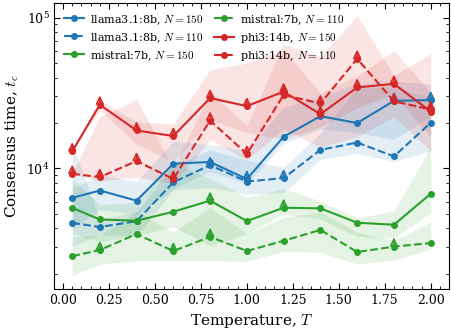

In [ ]:

# ── t_c vs Temperature: overlay of multiple (model, N) curves ──────────
def plot_tc_vs_T_overlay(
    curves: list,
    list_of_temp: list,
    criterion: str = 'equal_zero',
    figsize: tuple = None,
    log_x: bool = False,
    log_y: bool = True,
    show_errorbars: bool = True,
    error_style: str = 'band',       # 'bars' (recommended) or 'band'
    band_type: str = 'iqr',          # 'iqr' (default), 'sem', or 'std'
    band_alpha: float = 0.12,
    marker_style: str = 'o',
    marker_size: float = 4,
    capsize: float = 2.5,
    mark_partial: bool = True,
    legend_loc: str = 'best',
    legend_ncol: int = 2,
    legend_fontsize: float = 8,
    output_path: str = None,
    title: str = None,
):
    """
    Plot ALL given (model, N) curves on a SINGLE axis.

    The function creates ONE matplotlib figure with ONE axis. Each item
    in `curves` adds one curve. Suggested encoding:
        colour     → model
        linestyle  → N

    Parameters
    ----------
    curves : list of dicts, one per curve to plot. Each dict has keys:
        'configs'   : list of dicts in the standard cfg format
                      (same as plot_tc_vs_agents); only the first
                      element is used.
        'color'     : matplotlib colour (e.g. '#1f77b4' for llama)
        'linestyle' : '-', '--', ':', '-.'   (e.g. '-' for N=150, '--' for N=110)
        'label'     : legend label (e.g. 'llama3.1:8b, N=150')

    list_of_temp : temperatures for the x-axis.
    criterion    : 'less_than_log2', 'equal_zero', or 'equal_one'.
    band_type    : 'iqr' (median + IQR), 'sem' (mean + SEM), 'std' (mean + std).
    error_style  : 'bars' (recommended for overlays) or 'band'.
    figsize      : figure size in inches. Default: APS single-column-ish, slightly taller.
    log_x, log_y : axis scaling.
    legend_*     : legend formatting controls.
    output_path  : PDF/PNG save path.
    title        : optional figure title.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes.
    """
    # ── ONE figure, ONE axes ────────────────────────────────────────────
    if figsize is None:
        figsize = (APS_SINGLE_COL * 1.35, APS_SINGLE_COL * 1.0)
    fig, ax = plt.subplots(figsize=figsize)

    if band_type not in ('iqr', 'sem', 'std'):
        raise ValueError(f"band_type must be 'iqr', 'sem', or 'std', got {band_type!r}")

    # ── Loop over curves ────────────────────────────────────────────────
    for spec in curves:
        configs   = spec['configs']
        color     = spec.get('color', 'C0')
        linestyle = spec.get('linestyle', '-')
        label     = spec.get('label', None)

        if not isinstance(configs, list) or len(configs) == 0:
            raise ValueError("each curve's 'configs' must be a non-empty list of dicts")
        if len(configs) > 1:
            print(f"  Warning: {len(configs)} configs for label={label!r}, "
                  f"using only the first (N={configs[0]['N']}).")
        config = configs[0]
        N = config['N']

        print(f"  Curve: {label!r}  (N={N}, model={config['model']})")

        tc_T, tc_center, tc_lower, tc_upper, has_none_list = [], [], [], [], []

        for temp in sorted(list_of_temp):
            tc_list = _consensus_times_per_seed(
                config['folder'], config['model'], config['experiment'],
                config['seeds'], temp, criterion)
            if not tc_list:
                continue
            none_count = tc_list.count(None)
            valid = [t for t in tc_list if t is not None]
            if not valid:
                tc_T.append(temp); tc_center.append(np.nan)
                tc_lower.append(np.nan); tc_upper.append(np.nan)
                has_none_list.append(True)
                continue

            v = np.asarray(valid, dtype=float)
            if band_type == 'iqr':
                c  = np.median(v)
                lo = np.percentile(v, 25) if len(v) >= 2 else v[0]
                hi = np.percentile(v, 75) if len(v) >= 2 else v[0]
            else:
                c  = np.mean(v)
                sd = np.std(v, ddof=1) if len(v) > 1 else 0.0
                if band_type == 'sem':
                    sd = sd / np.sqrt(len(v))
                lo, hi = c - sd, c + sd

            tc_T.append(temp); tc_center.append(c)
            tc_lower.append(lo); tc_upper.append(hi)
            has_none_list.append(none_count > 0)

        if not tc_T:
            print(f"    No data, skipping.")
            continue

        x        = np.array(tc_T, dtype=float)
        y        = np.array(tc_center)
        y_lo     = np.array(tc_lower)
        y_hi     = np.array(tc_upper)
        has_none = np.array(has_none_list)
        yerr_lo  = y - y_lo
        yerr_hi  = y_hi - y
        all_valid = ~np.isnan(y)
        partial   = has_none & all_valid

        if not all_valid.any():
            continue

        order = np.argsort(x[all_valid])
        xo   = x[all_valid][order]
        yo   = y[all_valid][order]
        yloo = y_lo[all_valid][order]
        yhio = y_hi[all_valid][order]
        elo  = yerr_lo[all_valid][order]
        ehi  = yerr_hi[all_valid][order]

        # Central line
        ax.plot(xo, yo, color=color, marker=marker_style, ms=marker_size,
                lw=1.5, ls=linestyle, label=label, zorder=5)

        # Error bars or band
        if show_errorbars:
            if error_style == 'bars':
                ax.errorbar(xo, yo, yerr=np.array([elo, ehi]),
                            color=color, fmt='none',
                            capsize=capsize, lw=0.8, zorder=4)
            elif error_style == 'band':
                ax.fill_between(xo, yloo, yhio, color=color,
                                alpha=band_alpha, lw=0, zorder=2)

        # Lower-bound arrows for partial-convergence points
        if mark_partial and partial.any():
            for xi, yi in zip(x[partial], y[partial]):
                ax.annotate('', xy=(xi, yi * 1.15), xytext=(xi, yi * 1.02),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, shrinkA=0, shrinkB=0),
                            zorder=6)

    # ── Axes formatting (called ONCE, at the end) ───────────────────────
    ax.set_xlabel(r'Temperature, $T$')
    ax.set_ylabel(r'Consensus time, $t_c$')
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, fontsize=10)

    # ── Single legend at the end ────────────────────────────────────────
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(handles, labels, loc=legend_loc, ncol=legend_ncol,
                  columnspacing=1.0, handletextpad=0.5, borderpad=0.4,
                  labelspacing=0.4, frameon=False, fontsize=legend_fontsize)

    fig.tight_layout(pad=0.3)

    if output_path:
        fig.savefig(output_path)
        print(f"\n  Saved → {output_path}")

    return fig, ax



cfg_phi_110 = [
    {'folder': 'results_ji', 'model': 'phi3-14b', 'experiment': 'na110-n12e4',
     'seeds': [10,11,12,13,14,15,16,17,18,19,20,21,22,23], 'N': 110},
]
cfg_llama_110 = [
    {'folder': 'results_ji', 'model': 'llama3.1-8b', 'experiment': 'na110-n7e4',
     'seeds': [0,1,2,3,4,5,6,7], 'N': 110},
]

cfg_mis_110 = [
    {'folder': 'results_ji', 'model': 'mistral-7b', 'experiment': 'na110-n5e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16], 'N': 110},
]

cfg_phi_150 = [
    {'folder': 'results_ji', 'model': 'phi3-14b', 'experiment': 'na150-n15e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]
cfg_llama_150 = [
    {'folder': 'results_ji', 'model': 'llama3.1-8b', 'experiment': 'na1p5e2-ns7e4',
     'seeds': [0,1,2,3,4,5,6,7,8,9], 'N': 150},
]

cfg_mis_150 = [
    {'folder': 'results_ji', 'model': 'mistral-7b', 'experiment': 'na150-n9e4',
     'seeds': [6,7,8,9,10,11,12,13,14,15], 'N': 150},
]



curves = [
    {'configs': cfg_llama_150, 'color': '#1f77b4', 'linestyle': '-',
     'label': 'llama3.1:8b, $N=150$'},
    {'configs': cfg_llama_110, 'color': '#1f77b4', 'linestyle': '--',
     'label': 'llama3.1:8b, $N=110$'},

    {'configs': cfg_mis_150,   'color': '#2ca02c', 'linestyle': '-',
     'label': 'mistral:7b, $N=150$'},
    {'configs': cfg_mis_110,   'color': '#2ca02c', 'linestyle': '--',
     'label': 'mistral:7b, $N=110$'},

    {'configs': cfg_phi_150,   'color': '#d62728', 'linestyle': '-',
     'label': 'phi3:14b, $N=150$'},
    {'configs': cfg_phi_110,   'color': '#d62728', 'linestyle': '--',
     'label': 'phi3:14b, $N=110$'},
]

fig, ax = plot_tc_vs_T_overlay(curves, list_of_temp,
                                output_path='fig5_tc_vs_T_overlay.pdf')

## Average inventory size plots

In [8]:
# ══════════════════════════════════════════════════════════════════════
# Average inventory size  k_bar(t) = (1/N) * sum_i |P_i(t)|
#
# Reads num_of_words_*.json  (column: 'word_count' → sum of inventories)
# and divides by N to obtain the per-agent average.
#
# Style and behaviour mirror plot_nd_vs_steps.
# ══════════════════════════════════════════════════════════════════════

def _load_word_count(folder, model_name, seed, experiment, temp):
    """
    Load one seed's word_count series (== sum_i |P_i(t)|) from
    num_of_words_*.json. Uses the same dot/underscore T-fallback as
    the num_of_diff_words loader.
    """
    temp_str = f"{temp:g}"
    if '.' not in temp_str:
        temp_str += '.0'
    for ts in [temp_str, temp_str.replace('.', '_')]:
        fname = f"num_of_words_seed-{seed}_{experiment}_{model_name}_log_T-{ts}.json"
        path = Path(folder) / fname
        if path.exists():
            return pd.read_json(path)['word_count'].values.astype(float)
    return None


def _collect_kbar_seeds(folder, model_name, experiment, temp, seeds, N,
                        pad_mode='nan'):
    """
    Collect k_bar(t) = word_count(t) / N arrays across seeds for one
    temperature. Behaves like collect_seeds but for word_count.
    """
    arrays = []
    for s in seeds:
        y = _load_word_count(folder, model_name, s, experiment, temp)
        if y is not None:
            arrays.append(y / float(N))

    if not arrays:
        print(f"  ⚠  No data found for T={temp} (seeds={seeds})")
        return None

    max_len = max(len(a) for a in arrays)
    min_len = min(len(a) for a in arrays)

    padded = np.full((len(arrays), max_len), np.nan)
    for i, a in enumerate(arrays):
        padded[i, :len(a)] = a
        if pad_mode == 'ffill' and len(a) < max_len:
            padded[i, len(a):] = a[-1]

    if min_len < max_len:
        print(f"  T={temp}: {len(arrays)} seed(s), lengths {min_len}–{max_len} "
              f"(padded with {'last value' if pad_mode == 'ffill' else 'NaN'})")
    else:
        print(f"  T={temp}: {len(arrays)} seed(s), {max_len} steps")
    return padded


def plot_kbar_vs_steps(
    folder: str,
    model_name: str,
    experiment: str,
    seeds: list,
    list_of_temp: list,
    N: int,                              # agent count (for normalisation)
    max_steps: int = None,
    figsize: tuple = None,
    cmap_name: str = 'plasma',
    smoothing_window: int = 1,
    subsample: int = 50,
    show_bands: bool = True,
    band_alpha: float = 0.18,
    band_type: str = 'sem',              # 'sem' or 'std'
    log_y: bool = False,                 # linear by default (k_bar is small)
    use_colorbar: bool = False,
    output_path: str = None,
    title: str = None,
    ax: plt.Axes = None,
):
    """
    Publication-quality plot of the average inventory size
        k_bar(t) = (1/N) * sum_i |P_i(t)|
    vs interaction step, for different decoding temperatures.

    Direct analogue of plot_nd_vs_steps for the per-agent inventory size.

    Parameters
    ----------
    folder, model_name, experiment, seeds, list_of_temp :
        Same as plot_nd_vs_steps.
    N : int
        Number of agents (used to normalise word_count → k_bar).
    Other kwargs : same visual conventions as plot_nd_vs_steps.
    """
    own_fig = ax is None
    if own_fig:
        if figsize is None:
            figsize = (APS_SINGLE_COL, APS_SINGLE_COL * 0.75)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    norm = Normalize(vmin=min(list_of_temp), vmax=max(list_of_temp))
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    for temp in list_of_temp:
        data = _collect_kbar_seeds(folder, model_name, experiment, temp,
                                   seeds, N, pad_mode='nan')
        if data is None:
            continue

        if max_steps:
            data = data[:, :max_steps]

        mean_curve = np.nanmean(data, axis=0)
        std_curve  = np.nanstd(data, axis=0)
        n_valid    = np.sum(~np.isnan(data), axis=0)
        n_seeds    = data.shape[0]

        band_curve = (std_curve / np.sqrt(np.maximum(n_valid, 1))
                      if band_type == 'sem' else std_curve)

        mean_curve = smooth(mean_curve, smoothing_window)
        band_curve = smooth(band_curve, smoothing_window)

        steps = np.arange(len(mean_curve))
        color = cmap(norm(temp))
        idx = slice(None, None, subsample)

        if use_colorbar:
            ax.plot(steps[idx], mean_curve[idx], color=color, zorder=5)
        else:
            ax.plot(steps[idx], mean_curve[idx], color=color,
                    label=rf'$T={temp}$', zorder=5)

        if show_bands and n_seeds > 1:
            ax.fill_between(
                steps[idx],
                (mean_curve - band_curve)[idx],
                (mean_curve + band_curve)[idx],
                color=color, alpha=band_alpha, lw=0, zorder=2,
            )

    # ── Axes ────────────────────────────────────────────────────────────
    ax.set_xlabel(r'Interaction step, $t$')
    ax.set_ylabel(r'$\bar{k}(t) = N^{-1}\sum_i |P_i(t)|$')

    if log_y:
        ax.set_yscale('log')
    if title:
        ax.set_title(title, loc='left', fontsize=10)

    if max_steps and max_steps >= 1e4:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(
                lambda x, _: f'{x/1e3:.0f}' if x >= 1e3 else f'{x/1e3:.1f}'))
        ax.set_xlabel(r'Interaction step, $t\;[\times 10^3]$')

    if use_colorbar:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.9)
        cbar.set_label(r'$T$', fontsize=10)
        cbar.ax.tick_params(labelsize=8)
    else:
        ncol = 2 if len(list_of_temp) > 6 else 1
        ax.legend(loc='upper right', ncol=ncol, columnspacing=0.8,
                  handletextpad=0.4, borderpad=0.4, labelspacing=0.35)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=1.0)   # k_bar ≥ 1 once every agent has invented

    if own_fig:
        fig.tight_layout(pad=0.3)
    if output_path:
        fig.savefig(output_path)
        print(f"Saved → {output_path}")

    return fig, ax

  T=0.05: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.2: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.4: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.6: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.8: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.0: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.2: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.4: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.6: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.8: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=2.0: 10 seed(s), lengths 150000–175000 (padded with NaN)


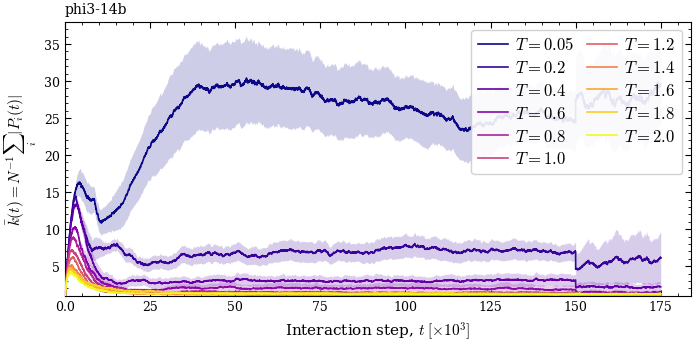

In [44]:
temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
all_seeds = [0,1,2,3,4,5,6,7,8,9]


MODEL = 'phi3-14b'
fig, ax = plot_kbar_vs_steps(
    folder='results_ji',
    model_name=MODEL,
    experiment='na150-n15e4',
    seeds=all_seeds,
    list_of_temp=temps,
    N=150,
    max_steps=180000,
    figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    subsample=20,
    band_type='sem',
    band_alpha=0.2,
    title=MODEL,
)
fig.savefig(f'./paper-images/pdfs/{MODEL}_kbar_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_kbar_vs_steps.png', dpi=400)

plt.show()

  T=0.05: 8 seed(s), 70000 steps
  T=0.2: 8 seed(s), 70000 steps
  T=0.4: 8 seed(s), 70000 steps
  T=0.6: 8 seed(s), 70000 steps
  T=0.8: 8 seed(s), 70000 steps
  T=1.0: 8 seed(s), 70000 steps
  T=1.2: 8 seed(s), 70000 steps
  T=1.4: 8 seed(s), 70000 steps
  T=1.6: 8 seed(s), 70000 steps
  T=1.8: 8 seed(s), 70000 steps
  T=2.0: 8 seed(s), 70000 steps


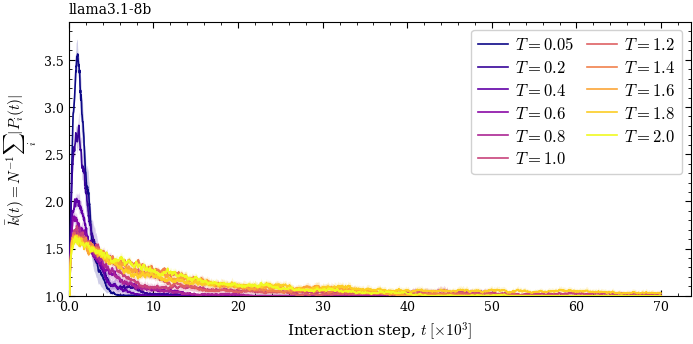

In [45]:
temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
all_seeds = [0,1,2,3,4,5,8,9]


MODEL = 'llama3.1-8b'
fig, ax = plot_kbar_vs_steps(
    folder='results_ji',
    model_name=MODEL,
    experiment='na1p5e2-ns7e4',
    seeds=all_seeds,
    list_of_temp=temps,
    N=150,
    max_steps=70000,
    figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    subsample=20,
    band_type='sem',
    band_alpha=0.2,
    title=MODEL,
)
fig.savefig(f'./paper-images/pdfs/{MODEL}_kbar_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_kbar_vs_steps.png', dpi=400)

plt.show()

  T=0.05: 10 seed(s), 120000 steps
  T=0.2: 10 seed(s), 120000 steps
  T=0.4: 10 seed(s), 120000 steps
  T=0.6: 10 seed(s), 120000 steps
  T=0.8: 10 seed(s), 120000 steps
  T=1.0: 10 seed(s), 120000 steps
  T=1.2: 10 seed(s), 120000 steps
  T=1.4: 10 seed(s), 120000 steps
  T=1.6: 10 seed(s), 120000 steps
  T=1.8: 10 seed(s), 120000 steps
  T=2.0: 10 seed(s), 120000 steps


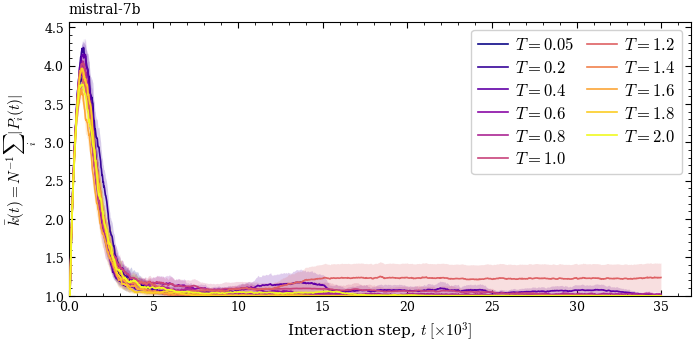

In [46]:
temps = [0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
all_seeds = [6,7,8,9,10,11,12,13,14,15]


MODEL = 'mistral-7b'
fig, ax = plot_kbar_vs_steps(
    folder='results_ji',
    model_name=MODEL,
    experiment='na150-n9e4',
    seeds=all_seeds,
    list_of_temp=temps,
    N=150,
    max_steps=35000,
    figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.5),
    subsample=20,
    band_type='sem',
    band_alpha=0.2,
    title=MODEL,
)
fig.savefig(f'./paper-images/pdfs/{MODEL}_kbar_vs_steps.pdf', bbox_inches='tight')
fig.savefig(f'./paper-images/pngs/{MODEL}_kbar_vs_steps.png', dpi=400)

plt.show()

  T=0.05: 8 seed(s), 70000 steps
  T=0.2: 8 seed(s), 70000 steps
  T=0.4: 8 seed(s), 70000 steps
  T=0.6: 8 seed(s), 70000 steps
  T=0.8: 8 seed(s), 70000 steps
  T=1.0: 8 seed(s), 70000 steps
  T=1.2: 8 seed(s), 70000 steps
  T=1.4: 8 seed(s), 70000 steps
  T=1.6: 8 seed(s), 70000 steps
  T=1.8: 8 seed(s), 70000 steps
  T=2.0: 8 seed(s), 70000 steps
  ⚠  No data found for T=0.05 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=0.2 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=0.4 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=0.6 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=0.8 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=1.0 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=1.2 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=1.4 (seeds=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
  ⚠  No data found for T=1.6 (seeds=[6, 7, 8, 9, 10, 1

/var/folders/50/vmzncmyj05v940yckw8fyfyr0000gp/T/ipykernel_45342/1784556677.py:172: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(bottom=1.0)   # k_bar ≥ 1 once every agent has invented


  T=0.05: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.2: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.4: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.6: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=0.8: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.0: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.2: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.4: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.6: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=1.8: 10 seed(s), lengths 150000–175000 (padded with NaN)
  T=2.0: 10 seed(s), lengths 150000–175000 (padded with NaN)


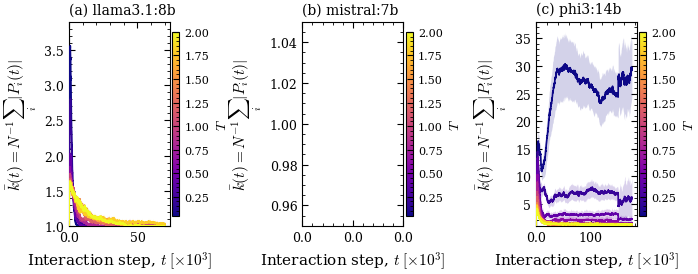

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(APS_DOUBLE_COL, APS_DOUBLE_COL * 0.4),
                         sharey=False)

plot_kbar_vs_steps(
    folder='results_ji', model_name='llama3.1-8b',
    experiment='na1p5e2-ns7e4', seeds=[0,1,2,3,4,5,8,9],
    list_of_temp=temps, N=150, max_steps=70000,
    subsample=20, use_colorbar=True, title='(a) llama3.1:8b', ax=axes[0],
)
plot_kbar_vs_steps(
    folder='results_ji', model_name='mistral-7b',
    experiment='na150-ns9e4',
    seeds=[6,7,8,9,10,11,12,13,14,15],
    list_of_temp=temps, N=150, max_steps=35000,
    subsample=20, use_colorbar=True, title='(b) mistral:7b', ax=axes[1],
)
plot_kbar_vs_steps(
    folder='results_ji', model_name='phi3-14b',
    experiment='na150-n15e4', seeds=[0,1,2,3,4,5,6,7,8,9],
    list_of_temp=temps, N=150, max_steps=180000,
    subsample=20, use_colorbar=True, title='(c) phi3:14b', ax=axes[2],
)

fig.tight_layout(pad=0.3)
fig.savefig('./paper-images/kbar_vs_steps_all_models.png', dpi=200)
plt.show()